In [1]:
import pandas as pd
import pandas as pd
#Add the imports here
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from datetime import datetime
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
from sklearn.impute import SimpleImputer
from scipy.stats import zscore
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import OneHotEncoder

In [2]:
#df.to_csv("shell_company_fraud_smallset.csv", index=False)
df = pd.read_csv('data/latest_shell_company_fraud_dataset.csv' , encoding='utf-8', low_memory=False)
df.columns = df.columns.str.strip()

In [3]:
df.head(5)

,LoanNr_ChkDgt,Name,City,State,Zip,Bank,BankState,NAICS,ApprovalDate,ApprovalFY,...,Late Payment,Annual Revenue,Net income,Credit Score,Taxed_filed,Business Licenses Status,Outstanding loans,Fraud Trend Over Time,fraud_incident,Purpose_of_credit
0,1000084002,"B&T SCREW MACHINE COMPANY, INC",PLAINVILLE,CT,6062,"TD BANK, NATIONAL ASSOCIATION",DE,Manufacturing,2/28/1997,1997,...,N,1.730830e+06,150539.304000,612,YES,YES,11.0,Stable,0,Equipment & Technology Upgrades
1,1000144007,PROFESSIONAL ELEVATOR SERVICES,CHICAGO,IL,60605,BANK OF AMERICA NATL ASSOC,OR,Construction,2/28/1997,1997,...,N,5.417385e+05,27314.406130,601,PENDING,RENEWAL DUE,8.0,Stable,0,Equipment & Technology Upgrades
2,1000506000,WEYLAND CORPORATION,CAMARILLO,CA,93010,WELLS FARGO BANK NATL ASSOC,SD,Educational services,2/7/2006,2006,...,N,2.636591e+06,131829.564900,497,PENDING,NOT REQUIRED,1.0,Stable,0,Working Capital & Cash Flow Management
3,1000524003,AUDELIA FAMILY DENTAL GROUP,DALLAS,TX,75243,THE FROST NATIONAL BANK,TX,Health care and social assistance,2/28/1997,1997,...,N,3.595876e+06,179793.796300,547,EXEMPT,RENEWAL DUE,13.0,Stable,1,Emergency & Unforeseen Expenses
4,1000735003,Mykols Marine Inc.,Spring Lake,MI,49417,WELLS FARGO BANK NATL ASSOC,SD,"Arts, entertainment, and recreation",3/31/1997,1997,...,N,1.290236e+05,6451.179845,628,EXEMPT,NOT REQUIRED,10.0,Stable,0,Equipment & Technology Upgrades


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99999 entries, 0 to 99998
Data columns (total 42 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   LoanNr_ChkDgt              99999 non-null  int64  
 1   Name                       99999 non-null  object 
 2   City                       99999 non-null  object 
 3   State                      99998 non-null  object 
 4   Zip                        99999 non-null  int64  
 5   Bank                       99818 non-null  object 
 6   BankState                  99817 non-null  object 
 7   NAICS                      99999 non-null  object 
 8   ApprovalDate               99999 non-null  object 
 9   ApprovalFY                 99999 non-null  int64  
 10  Term                       99999 non-null  int64  
 11  NoEmp                      99999 non-null  int64  
 12  NewExist                   99963 non-null  float64
 13  CreateJob                  99999 non-null  int

In [5]:
df.describe()

,LoanNr_ChkDgt,Zip,ApprovalFY,Term,NoEmp,NewExist,CreateJob,RetainedJob,FranchiseCode,UrbanRural,...,BalanceGross,ChgOffPrinGr,GrAppv,Sector_Code,NumOfapplications,Annual Revenue,Net income,Credit Score,Outstanding loans,fraud_incident
count,9.999900e+04,99999.000000,99999.000000,99999.000000,99999.000000,99963.000000,99999.000000,99999.000000,99999.000000,99999.000000,...,99999.000000,9.999900e+04,9.999900e+04,99999.000000,99999.000000,9.999900e+04,9.999900e+04,99999.000000,99877.000000,99999.000000
mean,3.269500e+09,55512.239132,2002.484255,121.334763,30.109151,1.142953,4.577216,15.035440,2672.778428,0.878909,...,1.779218,2.321478e+04,3.421559e+05,49.510475,4.258063,1.971312e+06,1.133619e+05,587.203882,10.072659,0.393524
std,1.199159e+09,30967.694067,5.989006,85.678133,122.824563,0.353043,28.617292,43.979102,12571.270974,0.606395,...,392.627994,1.081466e+05,4.152945e+05,17.915441,2.829382,2.515002e+06,1.560776e+05,132.241253,16.130307,0.488534
min,1.000084e+09,0.000000,1984.000000,0.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000e+00,5.000000e+02,11.000000,0.000000,0.000000e+00,0.000000e+00,100.000000,1.000000,0.000000
25%,2.329371e+09,30078.000000,1999.000000,60.000000,12.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000e+00,7.500000e+04,33.000000,2.000000,4.496868e+05,2.390046e+04,488.000000,4.000000,0.000000
50%,3.271756e+09,56301.000000,2002.000000,84.000000,18.000000,1.000000,0.000000,10.000000,1.000000,1.000000,...,0.000000,0.000000e+00,1.950000e+05,48.000000,3.000000,1.086940e+06,5.898477e+04,593.000000,7.000000,0.000000
75%,4.321649e+09,85012.000000,2007.000000,186.000000,30.000000,1.000000,4.000000,19.000000,1.000000,1.000000,...,0.000000,0.000000e+00,4.500000e+05,62.000000,8.000000,2.525467e+06,1.412011e+05,697.000000,10.000000,1.000000
max,5.352774e+09,99999.000000,2012.000000,404.000000,9992.000000,2.000000,5621.000000,9500.000000,91999.000000,2.000000,...,115820.000000,3.512596e+06,5.472000e+06,92.000000,9.000000,8.021306e+07,4.010653e+06,800.000000,100.000000,1.000000


In [6]:
# Lets convert the output/taregt values

# Convert target variable to numeric for correlation
df['Fraud/Shell company Fraud'] = df['Fraud/Shell company Fraud'].map({'P I F': 0, 'CHGOFF': 1})


In [7]:
#identified Duplicate rows
duplicates = df[df.duplicated()]
print(duplicates)

Empty DataFrame
Columns: [LoanNr_ChkDgt, Name, City, State, Zip, Bank, BankState, NAICS, ApprovalDate, ApprovalFY, Term, NoEmp, NewExist, CreateJob, RetainedJob, FranchiseCode, UrbanRural, RevLineCr, LowDoc, ChgOffDate, DisbursementDate, DisbursementGross, BalanceGross, Fraud/Shell company Fraud, ChgOffPrinGr, GrAppv, Sector_Code, Loan_backed_Realestate, NumOfapplications, Frequence_of_apps, payment_consistency, Credit Utilizations, Late Payment, Annual Revenue, Net income, Credit Score, Taxed_filed, Business Licenses Status, Outstanding loans, Fraud Trend Over Time, fraud_incident, Purpose_of_credit]
Index: []

[0 rows x 42 columns]


In [8]:
# Drop non-numeric columns
numerical_cols = df.select_dtypes(include=['int','float']).columns

# Compute correlation matrix
correlation_matrix = df[numerical_cols].corr()

# Extract correlation with Fraud column
fraud_correlation = correlation_matrix["Fraud/Shell company Fraud"].sort_values(ascending=False)
print(fraud_correlation)

Fraud/Shell company Fraud    1.000000
ChgOffPrinGr                 0.502408
ApprovalFY                   0.157410
UrbanRural                   0.109820
NewExist                     0.061344
Sector_Code                  0.039491
RetainedJob                  0.009306
Credit Score                 0.007498
fraud_incident               0.001898
BalanceGross                -0.001929
Zip                         -0.003512
FranchiseCode               -0.005663
NumOfapplications           -0.009650
CreateJob                   -0.014227
NoEmp                       -0.019944
Outstanding loans           -0.031473
Net income                  -0.098015
Annual Revenue              -0.103426
DisbursementGross           -0.110913
GrAppv                      -0.117327
LoanNr_ChkDgt               -0.189471
Term                        -0.296966
Name: Fraud/Shell company Fraud, dtype: float64


In [9]:
# Select non-numeric columns 
df_non_numeric = df.select_dtypes(exclude=['int', 'float'])
# Loop through each column and print unique values
for col in df_non_numeric.columns:
    print(f"Unique values in '{col}': {df[col].unique()[:20]} ...")  # Show only first 10 unique values


Unique values in 'Name': ['B&T SCREW MACHINE COMPANY, INC' 'PROFESSIONAL ELEVATOR SERVICES'
 'WEYLAND CORPORATION' 'AUDELIA FAMILY DENTAL GROUP' 'Mykols Marine Inc.'
 'ANGEL' 'LABELLE MARIEE, INC.' 'TULON PACIFIC LLC'
 'WOODLAND PUBLISHING, INC' 'TOUCHPOINTS MARKETING LLC'
 'Good Earth Produce Inc.' "SPOHN, INC DBA CULVER'S OF MT"
 'FOOD SOLUTIONS' 'EUROPEAN AUTO CENTER' 'Ferguson Animal Enterprises, I'
 'R.E. Stegall & Associates Inc.' 'NICHOLS, BROSCH, SANDOVAL & AS'
 'THE LAGUNITAS BREWING COMPANY' 'Sarni Cleaners of Boston, Inc.'
 'Crown Coatings LLC'] ...
Unique values in 'City': ['PLAINVILLE' 'CHICAGO' 'CAMARILLO' 'DALLAS' 'Spring Lake' 'LOS ANGELES'
 'KIRKLAND' 'IRVINE' 'PLEASANT GROVE' 'BELLE CHASSE' 'Olney' 'MT PLEASANT'
 'PASADENA' 'EL CERRITO' 'NORTH PROVIDENCE' 'Charlotte' 'CORAL GABLES'
 'PETALUMA' 'Boston' 'FISHERS (CORPORATE NAME FOR FI'] ...
Unique values in 'State': ['CT' 'IL' 'CA' 'TX' 'MI' 'WA' 'UT' 'LA' 'MD' 'RI' 'NC' 'FL' 'MA' 'IN'
 'NM' 'NV' 'MN' 'NY' 'AZ' 'VT'] .

In [10]:
df.head(10)

,LoanNr_ChkDgt,Name,City,State,Zip,Bank,BankState,NAICS,ApprovalDate,ApprovalFY,...,Late Payment,Annual Revenue,Net income,Credit Score,Taxed_filed,Business Licenses Status,Outstanding loans,Fraud Trend Over Time,fraud_incident,Purpose_of_credit
0,1000084002,"B&T SCREW MACHINE COMPANY, INC",PLAINVILLE,CT,6062,"TD BANK, NATIONAL ASSOCIATION",DE,Manufacturing,2/28/1997,1997,...,N,1.730830e+06,150539.304000,612,YES,YES,11.0,Stable,0,Equipment & Technology Upgrades
1,1000144007,PROFESSIONAL ELEVATOR SERVICES,CHICAGO,IL,60605,BANK OF AMERICA NATL ASSOC,OR,Construction,2/28/1997,1997,...,N,5.417385e+05,27314.406130,601,PENDING,RENEWAL DUE,8.0,Stable,0,Equipment & Technology Upgrades
2,1000506000,WEYLAND CORPORATION,CAMARILLO,CA,93010,WELLS FARGO BANK NATL ASSOC,SD,Educational services,2/7/2006,2006,...,N,2.636591e+06,131829.564900,497,PENDING,NOT REQUIRED,1.0,Stable,0,Working Capital & Cash Flow Management
3,1000524003,AUDELIA FAMILY DENTAL GROUP,DALLAS,TX,75243,THE FROST NATIONAL BANK,TX,Health care and social assistance,2/28/1997,1997,...,N,3.595876e+06,179793.796300,547,EXEMPT,RENEWAL DUE,13.0,Stable,1,Emergency & Unforeseen Expenses
4,1000735003,Mykols Marine Inc.,Spring Lake,MI,49417,WELLS FARGO BANK NATL ASSOC,SD,"Arts, entertainment, and recreation",3/31/1997,1997,...,N,1.290236e+05,6451.179845,628,EXEMPT,NOT REQUIRED,10.0,Stable,0,Equipment & Technology Upgrades
5,1000746002,ANGEL,LOS ANGELES,CA,60014,BBCN BANK,CA,Manufacturing,2/7/2006,2006,...,N,2.950828e+05,21851.532240,454,EXEMPT,YES,1.0,Stable,0,Working Capital & Cash Flow Management
6,1000764005,"LABELLE MARIEE, INC.",KIRKLAND,WA,98033,BANK OF AMERICA NATL ASSOC,WA,Retail trade,2/28/1997,1997,...,N,2.214847e+05,11074.234950,725,PENDING,NOT REQUIRED,5.0,Stable,0,Emergency & Unforeseen Expenses
7,1000816010,TULON PACIFIC LLC,IRVINE,CA,92618,WELLS FARGO BANK NATL ASSOC,SD,Wholesale trade,2/7/2006,2006,...,N,3.488753e+06,174437.663900,488,EXEMPT,RENEWAL DUE,15.0,Stable,0,Business Expansion & Growth
8,1000844005,"WOODLAND PUBLISHING, INC",PLEASANT GROVE,UT,84062,MOUNTAIN W. SMALL BUS. FINAN,UT,Manufacturing,2/28/1997,1997,...,N,7.115627e+05,46337.090610,778,PENDING,RENEWAL DUE,1.0,Stable,1,Marketing & Advertising
9,1000926008,TOUCHPOINTS MARKETING LLC,BELLE CHASSE,LA,70037,GULF COAST BK & TR CO,LA,"Professional, scientific, and technical services",2/7/2006,2006,...,N,9.803569e+05,49017.846900,483,EXEMPT,NOT REQUIRED,4.0,Stable,1,Working Capital & Cash Flow Management


LoanNr_ChkDgt                 0.000000
Name                          0.000000
City                          0.000000
State                         0.001000
Zip                           0.000000
Bank                          0.181002
BankState                     0.182002
NAICS                         0.000000
ApprovalDate                  0.000000
ApprovalFY                    0.000000
Term                          0.000000
NoEmp                         0.000000
NewExist                      0.036000
CreateJob                     0.000000
RetainedJob                   0.000000
FranchiseCode                 0.000000
UrbanRural                    0.000000
RevLineCr                     0.264003
LowDoc                        0.000000
ChgOffDate                   84.408844
DisbursementDate              0.275003
DisbursementGross             0.000000
BalanceGross                  0.000000
Fraud/Shell company Fraud     0.149001
ChgOffPrinGr                  0.000000
GrAppv                   

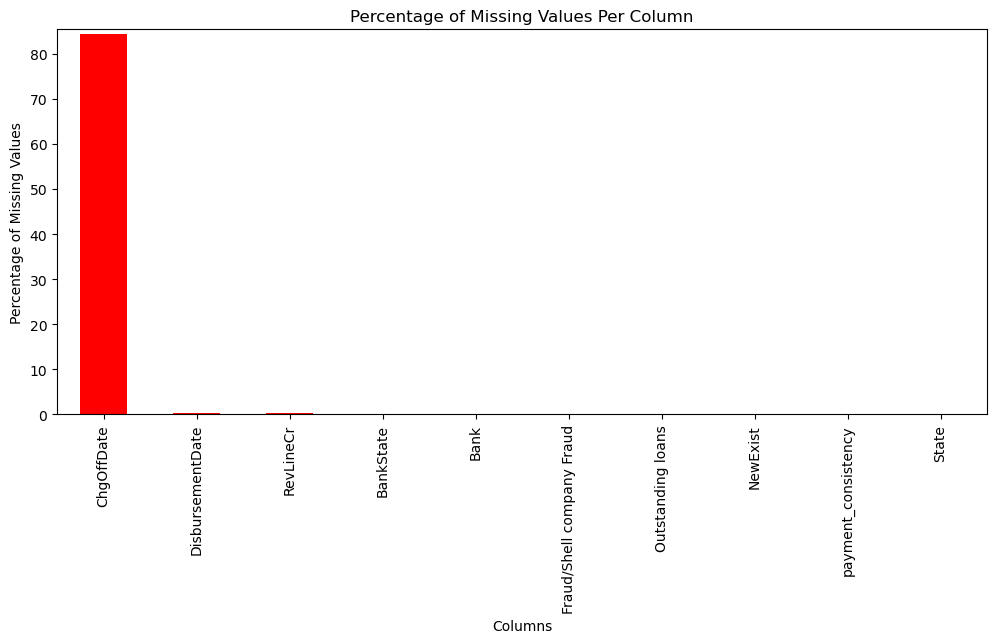

In [11]:
print(df.isnull().mean() * 100)

missing_values = df.isnull().sum().sort_values(ascending=False)
print("Missing Values Count:\n", missing_values[missing_values > 0])

missing_percent = (df.isnull().sum() / len(df)) * 100
missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)

plt.figure(figsize=(12, 5))
missing_percent.plot(kind="bar", color="red")

plt.title("Percentage of Missing Values Per Column")
plt.xlabel("Columns")
plt.ylabel("Percentage of Missing Values")
plt.xticks(rotation=90)

#This is to show missing values for features which are less than 1%
plt.ylim(0, max(missing_percent) + 1)  # Adjust the y-axis to include small percentages
plt.savefig("images/missing_data_metrics.png", dpi=300)
plt.show()

In [12]:
#Lets drop columns that do not add values and has no data 

df_clean = df.drop(columns=['LoanNr_ChkDgt','ChgOffDate','ApprovalDate','ApprovalFY','DisbursementDate', 'Fraud Trend Over Time','Name','City','Bank','BalanceGross','ChgOffPrinGr','GrAppv','Sector_Code','Frequence_of_apps'], axis=1)
df_clean.info()

#Outstanding loans, Fraud/Shell company Fraud, Bank, BankState, RevLineCr, payment_consistency

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99999 entries, 0 to 99998
Data columns (total 28 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   State                      99998 non-null  object 
 1   Zip                        99999 non-null  int64  
 2   BankState                  99817 non-null  object 
 3   NAICS                      99999 non-null  object 
 4   Term                       99999 non-null  int64  
 5   NoEmp                      99999 non-null  int64  
 6   NewExist                   99963 non-null  float64
 7   CreateJob                  99999 non-null  int64  
 8   RetainedJob                99999 non-null  int64  
 9   FranchiseCode              99999 non-null  int64  
 10  UrbanRural                 99999 non-null  int64  
 11  RevLineCr                  99735 non-null  object 
 12  LowDoc                     99999 non-null  object 
 13  DisbursementGross          99999 non-null  int

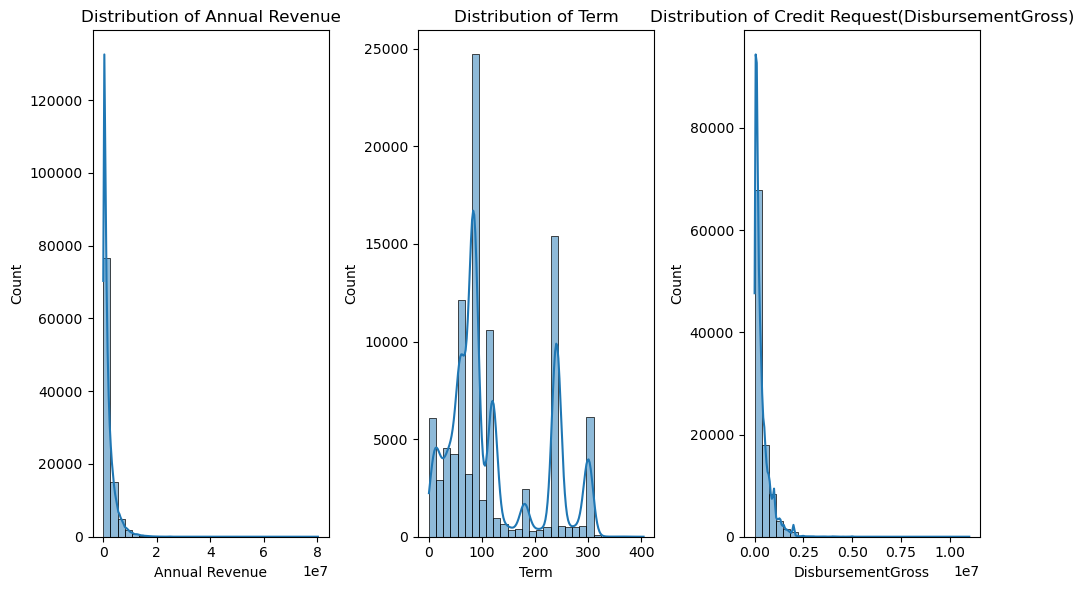

In [13]:
#Lets do some univariant and bivariant analysis and correlation heatmap to understand the relationship between the independent and dependent variables

# Histogram for Annual Revenue
fig, axes = plt.subplots(1, 3, figsize=(10, 6))
sns.histplot(df_clean['Annual Revenue'], bins=30, kde=True,ax=axes[0])
axes[0].set_title("Distribution of Annual Revenue")

sns.histplot(df_clean['Term'], bins=30, kde=True,ax=axes[1])
axes[1].set_title("Distribution of Term")

sns.histplot(df_clean['DisbursementGross'], bins=30, kde=True, ax=axes[2])
axes[2].set_title("Distribution of Credit Request(DisbursementGross)")

plt.tight_layout()  # Adjust spacing
plt.savefig("images/barplot_for_Distribution_metrics.png", dpi=300)
plt.show()


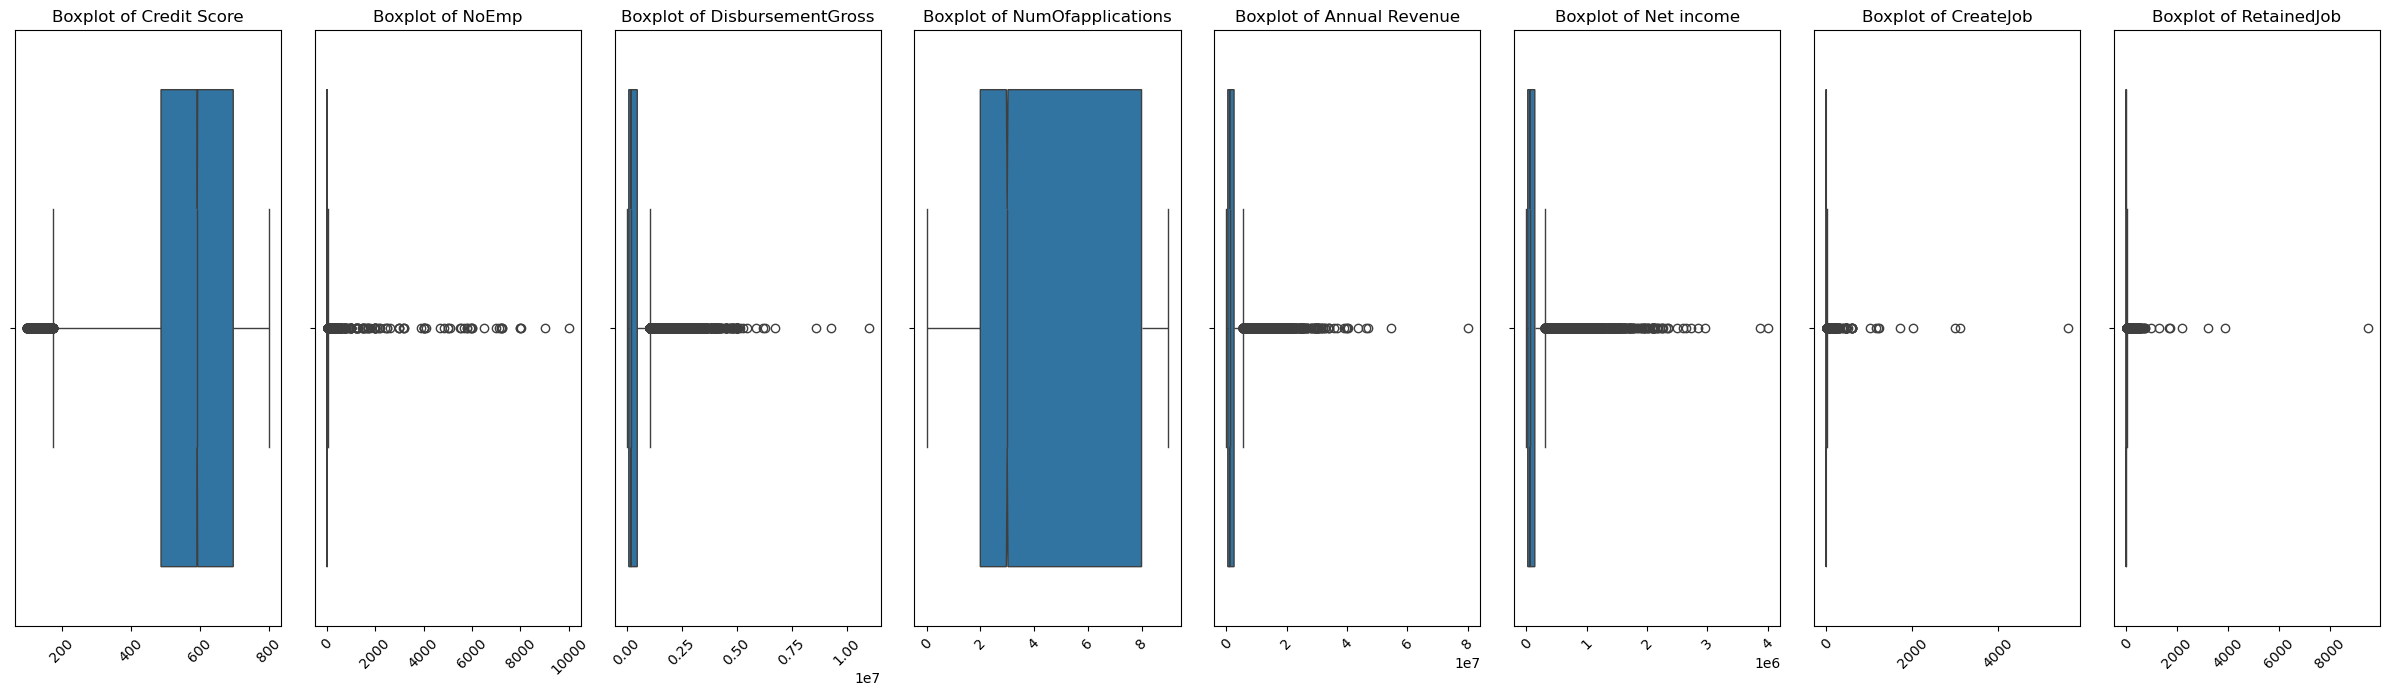

In [14]:
# Boxplot for detecting outliers - NoEmp, Term, DisbursementGross, NumOfApplications, Annual Revenue, Net Income, Credit Score
import matplotlib.pyplot as plt
import seaborn as sns

# Define columns for boxplots
columns = ['Credit Score', 'NoEmp', 'DisbursementGross', 'NumOfapplications', 
           'Annual Revenue', 'Net income', 'CreateJob','RetainedJob']

# Filter out missing columns (to prevent KeyError)
columns = [col for col in columns if col in df_clean.columns]

# Set up subplots dynamically based on available columns
fig, axes = plt.subplots(1, len(columns), figsize=(3 * len(columns), 7))  # Adjust width dynamically

# Ensure axes is iterable (handles cases where only one column exists)
if len(columns) == 1:
    axes = [axes]

# Loop through each column and plot boxplots
for i, col in enumerate(columns):
    sns.boxplot(x=df[col], ax=axes[i], notch=True)
    axes[i].set_title(f"Boxplot of {col}")
    axes[i].set_xlabel("")  # Remove x-axis label for clarity
    axes[i].tick_params(axis='x', rotation=45)  # Rotate x-ticks if necessary

# Adjust layout and spacing
plt.subplots_adjust(wspace=0.5)  # Increase spacing between plots for clarity
plt.tight_layout()
plt.savefig("images/boxplot_for_Outlier_metrics.png", dpi=300)
plt.show()


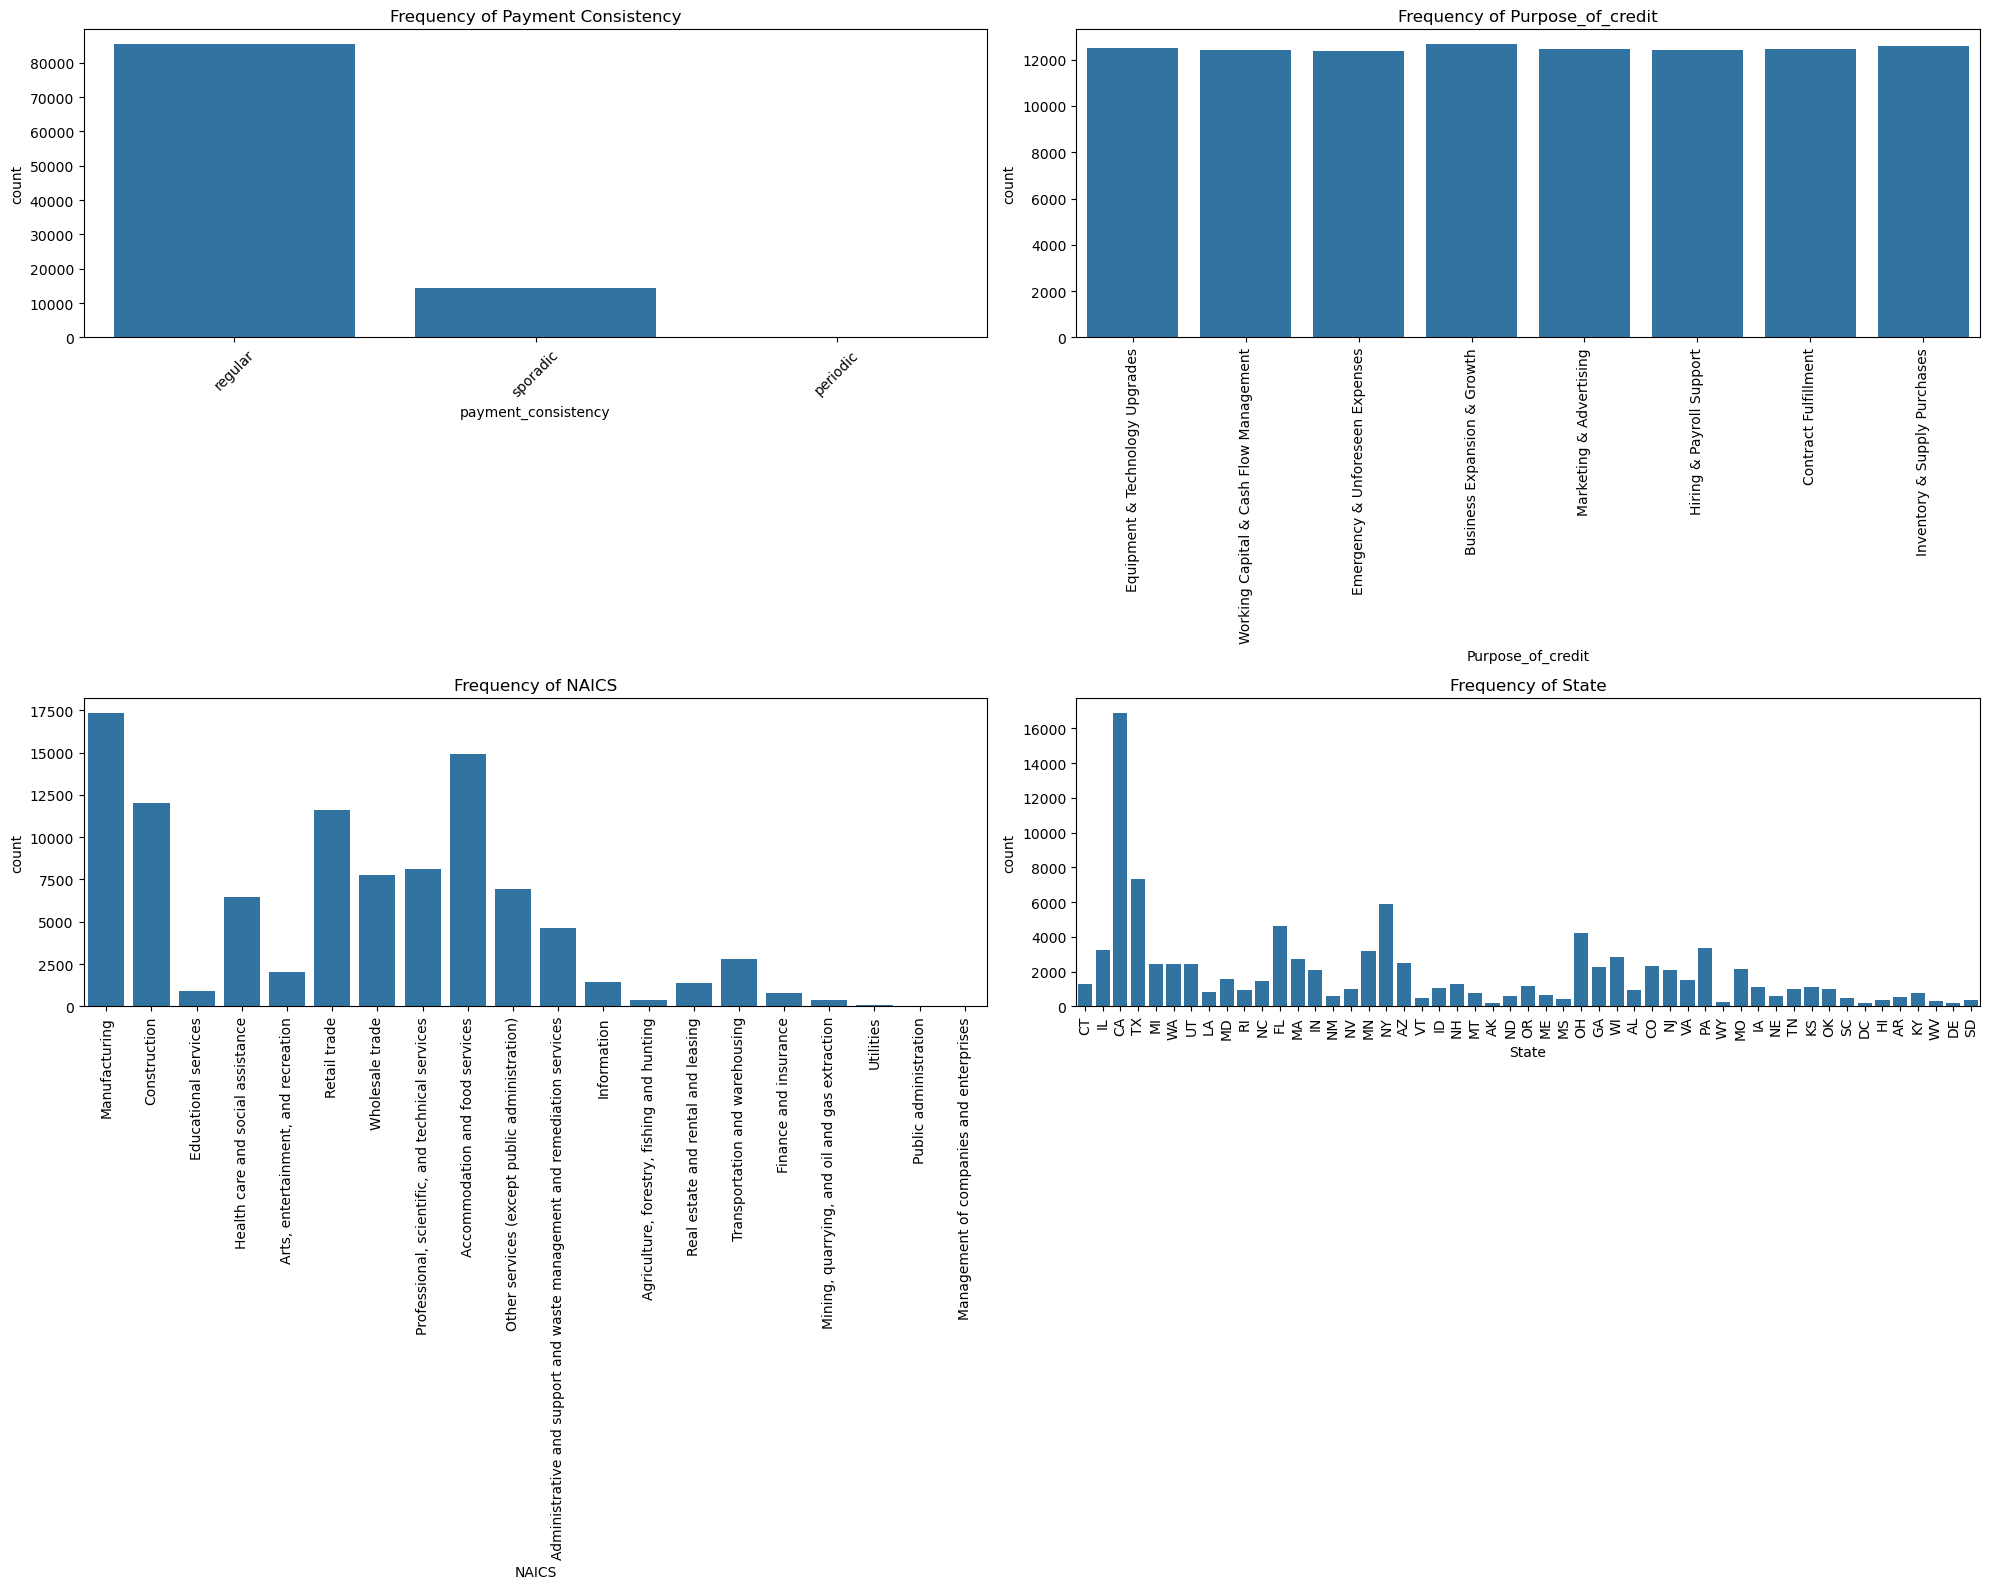

In [15]:
#Frequence of the variable State, Loan Purpose, Payment Consistency
# Bar chart for Payment Consistency
# Create a figure with subplots (2 rows, 2 columns)
fig, axes = plt.subplots(2, 2, figsize=(20, 16))

# Plot 1: Payment Consistency
sns.countplot(x=df_clean['payment_consistency'], ax=axes[0, 0])
axes[0, 0].set_title("Frequency of Payment Consistency")
axes[0, 0].tick_params(axis='x', rotation=45)

# Plot 2: Purpose of Credit
sns.countplot(x=df_clean['Purpose_of_credit'], ax=axes[0, 1])
axes[0, 1].set_title("Frequency of Purpose_of_credit")
axes[0, 1].tick_params(axis='x', rotation=90)

# Plot 3: NAICS
sns.countplot(x=df_clean['NAICS'], ax=axes[1, 0])
axes[1, 0].set_title("Frequency of NAICS")
axes[1, 0].tick_params(axis='x', rotation=90)

# Plot 4: State
sns.countplot(x=df_clean['State'], ax=axes[1, 1])
axes[1, 1].set_title("Frequency of State")
axes[1, 1].tick_params(axis='x', rotation=90)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.savefig("images/barplot_for_Frequency_metrics.png", dpi=300)
plt.show()


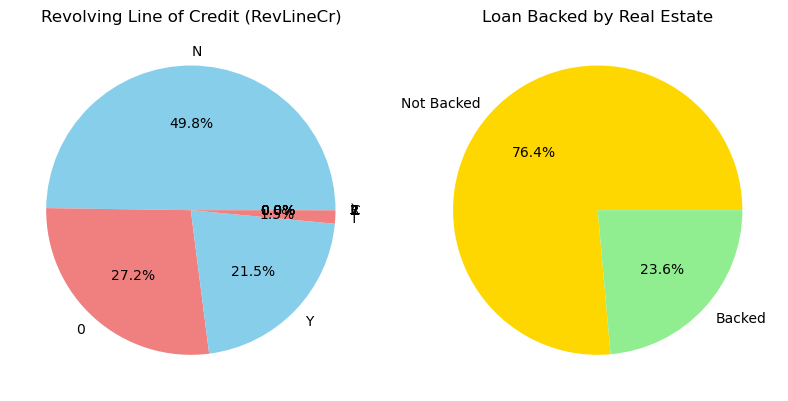

In [16]:
#Pie Chart	Proportion of categories	Loan-backed Real Estate, RevLineCr	df['RevLineCr'].value_counts().plot.pie()
#KDE Plot	Smooth distribution of numerical data	Net Income, Balance Gross	sns.kdeplot(df['Net income'], shade=True)

# Create a figure with 1 row, 2 columns for subplots
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# Pie Chart 1: `RevLineCr`
df_clean['RevLineCr'].value_counts().plot.pie(autopct='%1.1f%%', ax=axes[0], colors=['skyblue', 'lightcoral'])
axes[0].set_title("Revolving Line of Credit (RevLineCr)")
axes[0].set_ylabel('')  # Hide y-label for better display

# Pie Chart 2: `Loan_backed_Realestate`
df_clean['Loan_backed_Realestate'].value_counts().plot.pie(autopct='%1.1f%%', ax=axes[1], colors=['gold', 'lightgreen'])
axes[1].set_title("Loan Backed by Real Estate")
axes[1].set_ylabel('')  # Hide y-label for better display

# Display the pie charts
plt.tight_layout()
plt.savefig("images/piechart_for_distribution_percentage_metrics.png", dpi=300)
plt.show()

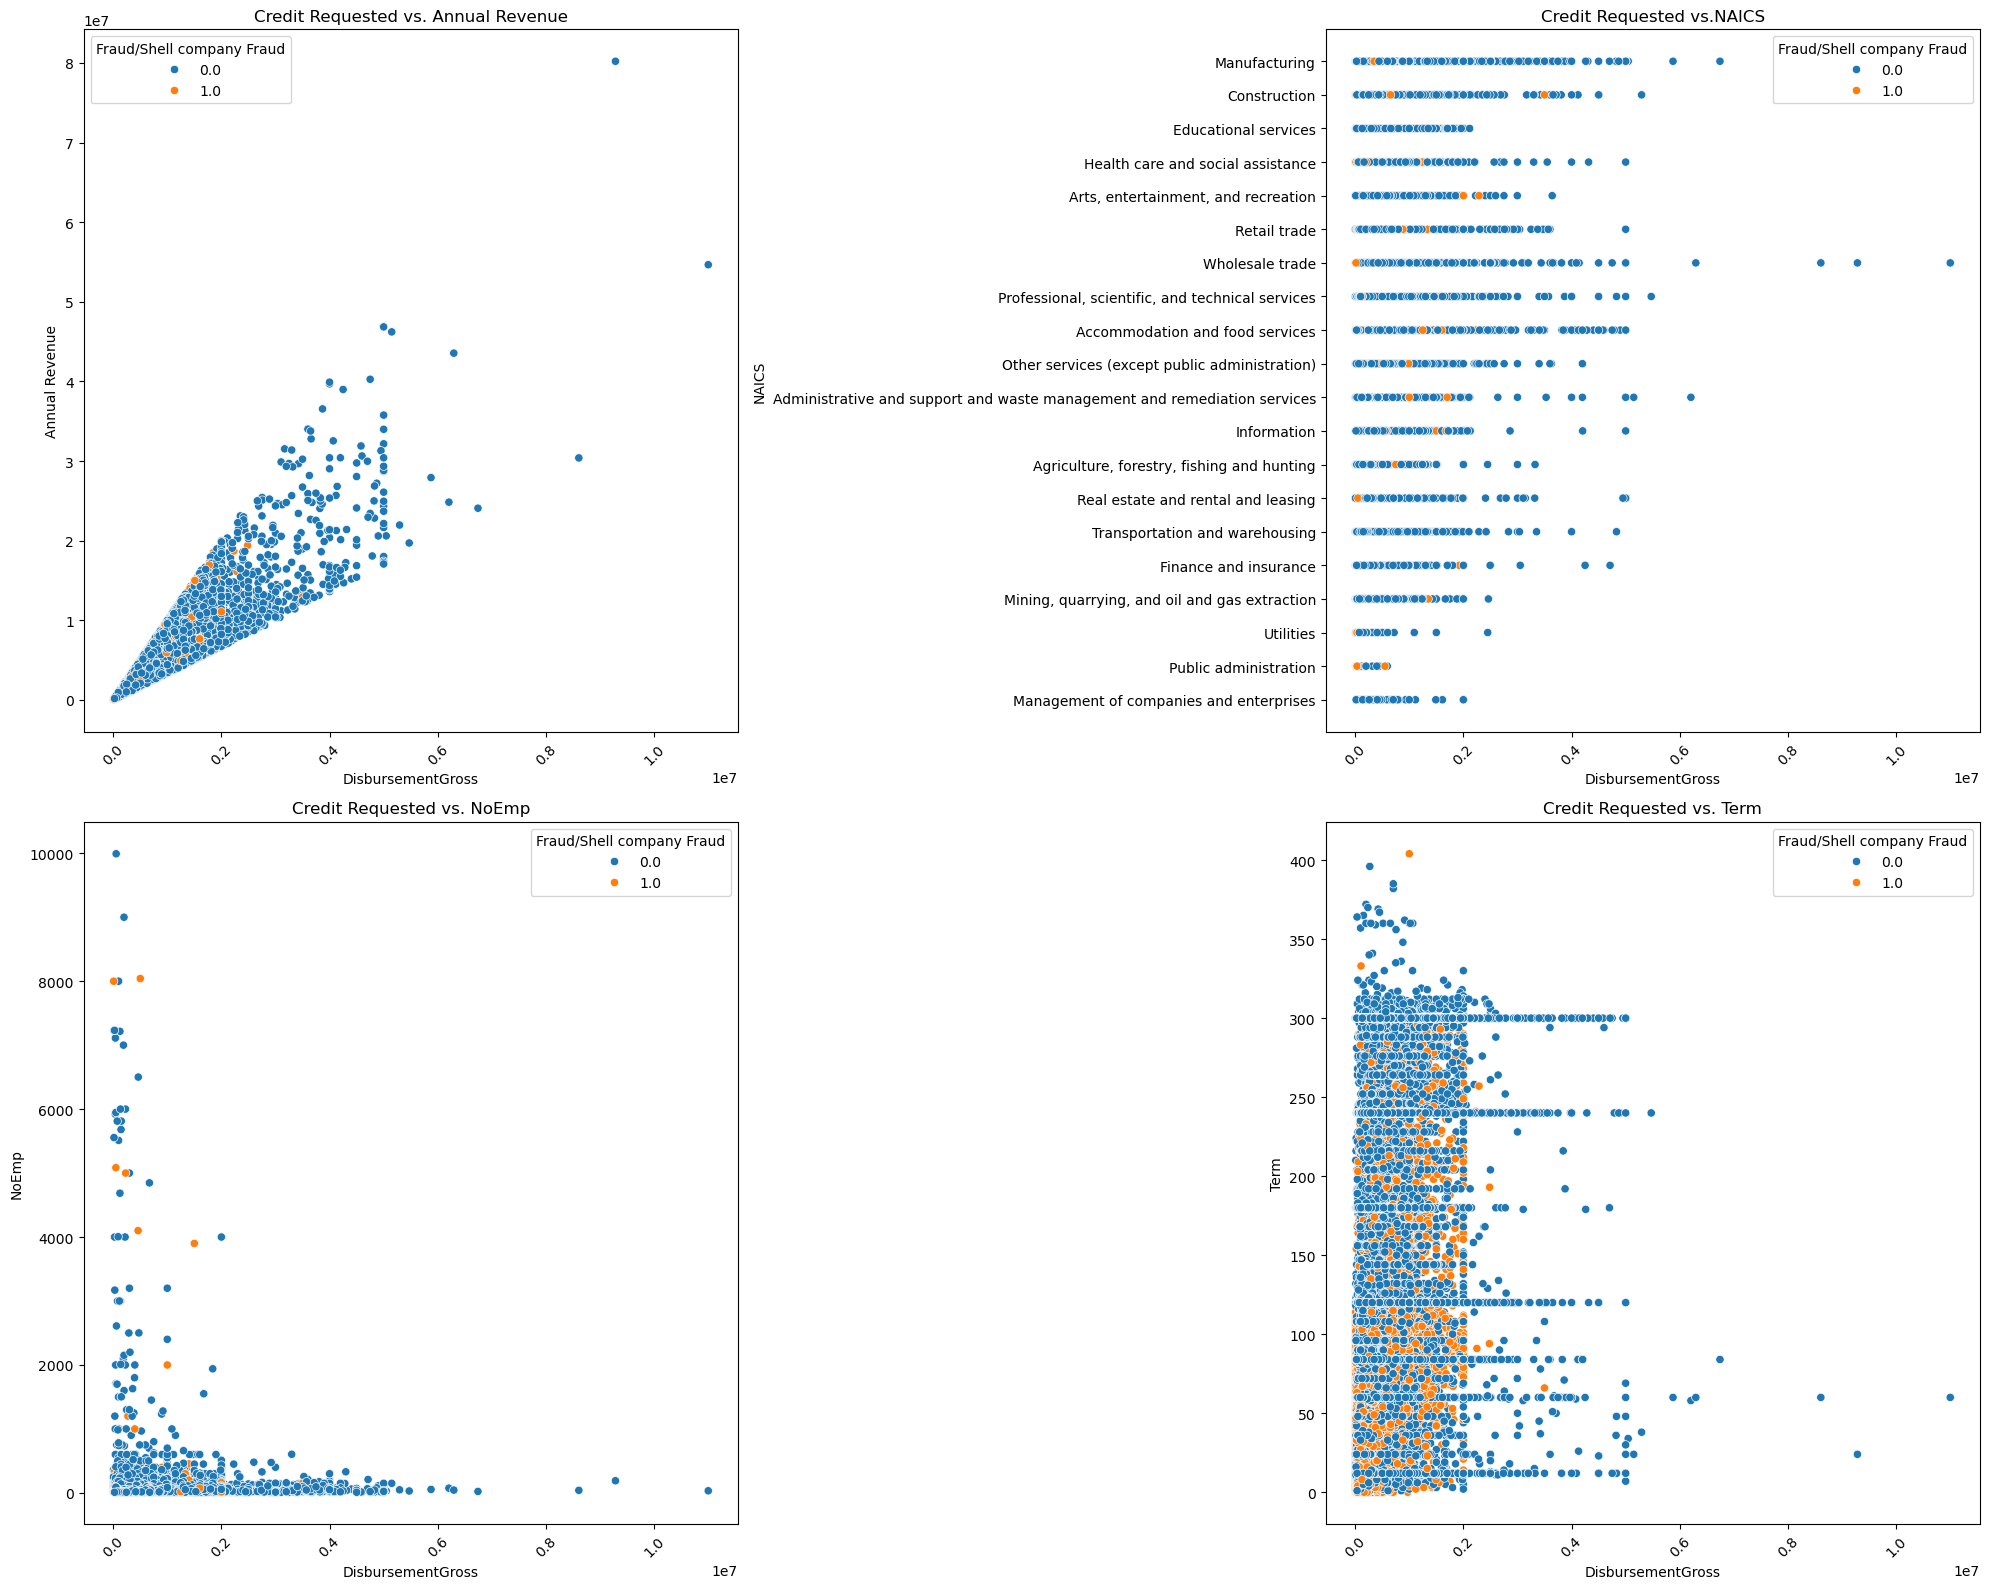

In [17]:
#Bivariant analysis 
fig, axes = plt.subplots(2, 2, figsize=(20, 16))
sns.scatterplot(x=df_clean['DisbursementGross'], y=df_clean['Annual Revenue'], ax=axes[0, 0], hue=df_clean['Fraud/Shell company Fraud'])
axes[0, 0].set_title("Credit Requested vs. Annual Revenue")
axes[0, 0].tick_params(axis='x', rotation=45)

sns.scatterplot(x=df_clean['DisbursementGross'], y=df_clean['NAICS'], ax=axes[0, 1], hue=df_clean['Fraud/Shell company Fraud'])
axes[0, 1].set_title("Credit Requested vs.NAICS")
axes[0, 1].tick_params(axis='x', rotation=45)

sns.scatterplot(x=df_clean['DisbursementGross'], y=df_clean['NoEmp'], ax=axes[1, 0], hue=df_clean['Fraud/Shell company Fraud'])
axes[1, 0].set_title("Credit Requested vs. NoEmp")
axes[1, 0].tick_params(axis='x', rotation=45)

sns.scatterplot(x=df_clean['DisbursementGross'], y=df_clean['Term'], ax=axes[1, 1], hue=df_clean['Fraud/Shell company Fraud'])
axes[1, 1].set_title("Credit Requested vs. Term")
axes[1, 1].tick_params(axis='x', rotation=45)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.savefig("images/scatterplot_for_creditRequestedvsfeatures.png", dpi=300)
plt.show()


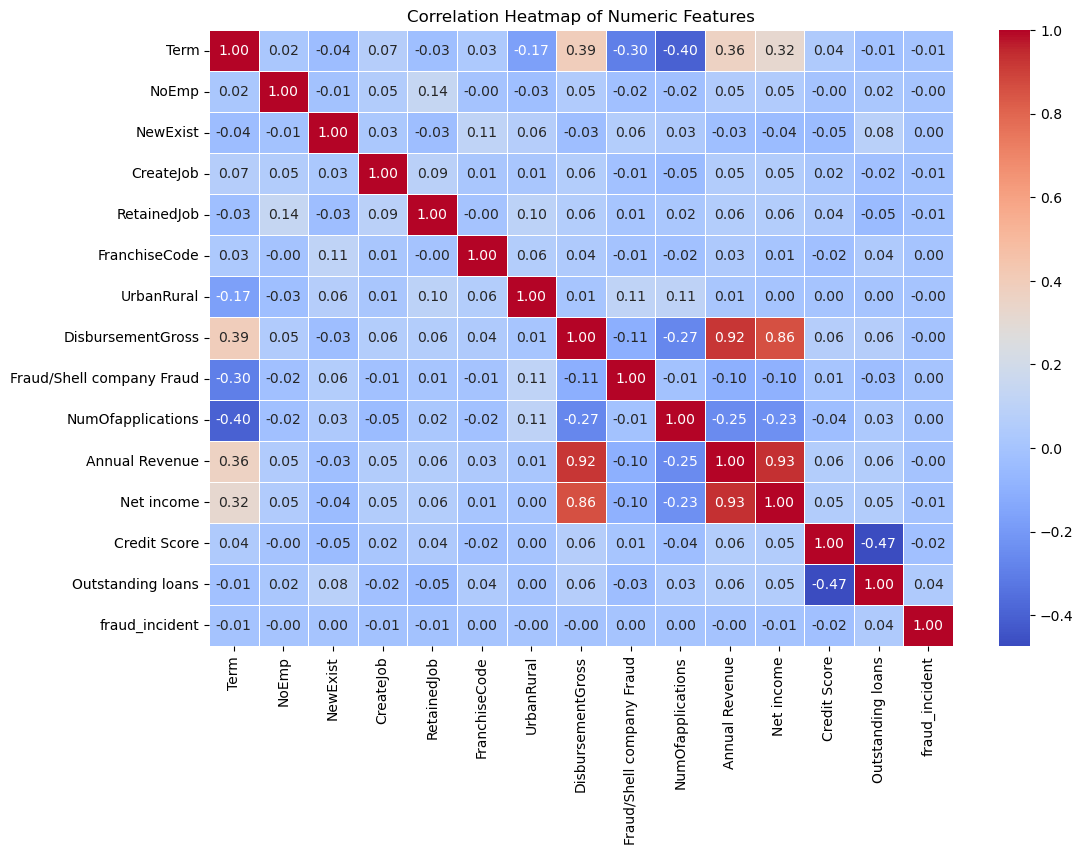

In [18]:
# Heatmap - Correlation Matrix
# Select only numeric columns
numeric_df = df_clean.select_dtypes(include=['int','float'])  # Keeps only numerical columns

numeric_df= numeric_df.drop(columns=['Zip'], axis=1)
# Compute correlation matrix
correlation_matrix = numeric_df.corr()

# Plot the heatmap
plt.figure(figsize=(12, 8))  # Adjust figure size
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Numeric Features")
plt.savefig("images/heatmap_for_correlation.png", dpi=300)
plt.show()

In [19]:
#Drop other unwanted columns
# Step 2: Impute missing 'Annual Revenue' with the median value
revenue_imputer = SimpleImputer(strategy='median')
df_clean['Annual Revenue'] = revenue_imputer.fit_transform(df_clean[['Annual Revenue']])

#Step 3 : Impute missing 'Outstanding loans' with the median value
df_clean['Outstanding loans'] = df_clean['Outstanding loans'].fillna(df_clean['Outstanding loans'].median())

# Categorical columns: Fill missing values with Mode (Most Frequent Value)
for col in ['Fraud/Shell company Fraud', 'BankState', 'RevLineCr', 'payment_consistency','NewExist', 'State']:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])  # mode()[0] gets the most frequent value



In [20]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99999 entries, 0 to 99998
Data columns (total 28 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   State                      99999 non-null  object 
 1   Zip                        99999 non-null  int64  
 2   BankState                  99999 non-null  object 
 3   NAICS                      99999 non-null  object 
 4   Term                       99999 non-null  int64  
 5   NoEmp                      99999 non-null  int64  
 6   NewExist                   99999 non-null  float64
 7   CreateJob                  99999 non-null  int64  
 8   RetainedJob                99999 non-null  int64  
 9   FranchiseCode              99999 non-null  int64  
 10  UrbanRural                 99999 non-null  int64  
 11  RevLineCr                  99999 non-null  object 
 12  LowDoc                     99999 non-null  object 
 13  DisbursementGross          99999 non-null  int

In [21]:
##FranchiseCode 0 or 1 is no franchise - otherwise its franchise
df_clean['FranchiseCode'] = df_clean['FranchiseCode'].apply(lambda x: 0 if x <= 1 else 1)

In [22]:
#converting categorical data to numerical data 
#state, zipcode, NAICS, Loan_backed_Realestate, RevLineCr, LowDoc, Frequence_of_apps ,payment_consistency, Credit Utilizations, late_payment, Tax_filee, Business_license_status, Purpose of credit.         
#converting zipcode by using frequency encoding

# Frequency Encoding for Zipcode, RevLinCr
zip_counts = df_clean['Zip'].value_counts()  
df_clean['Zip'] = df_clean['Zip'].map(zip_counts)  
RevLinCr_counts = df_clean['RevLineCr'].value_counts()  
df_clean['RevLinCr'] = df_clean['RevLineCr'].map(RevLinCr_counts)

#Binary Encoding for columns
binary_columns = ['Loan_backed_Realestate', 'LowDoc', 'Late Payment']
for col in binary_columns:
    df_clean[col] = df_clean[col].map({'Yes': 1, 'No': 0, 'Y': 1, 'N': 0, 'Backed':1, 'Not Backed':0})

#Ordinal encoding
ordinal_mapping = {
    'payment_consistency': {'None':0, 'sporadic': 1, 'periodic': 2, 'regular': 3 },
    'Credit Utilizations': {'No data': 1, 'Low': 2, 'High': 3},
    'Taxed_filed':{'NO':0, 'PENDING': 1, 'LATE':2, 'YES':3,'EXEMPT':4},
    'Business Licenses Status':{'NO':0, 'EXPIRED': 1, 'UNDER AUDIT': 2,'RENEWAL DUE': 3,'NOT REQUIRED': 4,'YES': 5}
}
for col, mapping in ordinal_mapping.items():
    df_clean[col] = df_clean[col].map(mapping)

#target Encoding for State. Compute target mean per category
state_target_mean = df_clean.groupby('State')['fraud_incident'].mean()
bank_state_target_mean = df_clean.groupby('BankState')['fraud_incident'].mean()

# Apply target encoding
df_clean['State'] = df_clean['State'].map(state_target_mean)
df_clean['BankState']=df_clean['BankState'].map(bank_state_target_mean)

df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99999 entries, 0 to 99998
Data columns (total 29 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   State                      99999 non-null  float64
 1   Zip                        99999 non-null  int64  
 2   BankState                  99999 non-null  float64
 3   NAICS                      99999 non-null  object 
 4   Term                       99999 non-null  int64  
 5   NoEmp                      99999 non-null  int64  
 6   NewExist                   99999 non-null  float64
 7   CreateJob                  99999 non-null  int64  
 8   RetainedJob                99999 non-null  int64  
 9   FranchiseCode              99999 non-null  int64  
 10  UrbanRural                 99999 non-null  int64  
 11  RevLineCr                  99999 non-null  object 
 12  LowDoc                     99999 non-null  int64  
 13  DisbursementGross          99999 non-null  int

In [23]:
#One Hot encoding for NAICS and Purpose_of_credit

# Perform one-hot encoding
encoded_condition = pd.get_dummies(df_clean['NAICS'], prefix='NAICS').astype(int)
# Combine with original DataFrame
df_clean = pd.concat([df_clean, encoded_condition], axis=1)

# Perform one-hot encoding
encoded_condition_purpose = pd.get_dummies(df_clean['Purpose_of_credit'], prefix='Purpose_of_credit').astype(int)

# Combine with original DataFrame
df_clean = pd.concat([df_clean, encoded_condition_purpose], axis=1)

In [24]:
df_clean.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99999 entries, 0 to 99998
Data columns (total 57 columns):
 #   Column                                                                          Non-Null Count  Dtype  
---  ------                                                                          --------------  -----  
 0   State                                                                           99999 non-null  float64
 1   Zip                                                                             99999 non-null  int64  
 2   BankState                                                                       99999 non-null  float64
 3   NAICS                                                                           99999 non-null  object 
 4   Term                                                                            99999 non-null  int64  
 5   NoEmp                                                                           99999 non-null  int64  
 6   NewExist      

In [25]:
#lets change column name for better readability 
df_clean.columns = df_clean.columns.str.replace(" ", "_")
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99999 entries, 0 to 99998
Data columns (total 57 columns):
 #   Column                                                                          Non-Null Count  Dtype  
---  ------                                                                          --------------  -----  
 0   State                                                                           99999 non-null  float64
 1   Zip                                                                             99999 non-null  int64  
 2   BankState                                                                       99999 non-null  float64
 3   NAICS                                                                           99999 non-null  object 
 4   Term                                                                            99999 non-null  int64  
 5   NoEmp                                                                           99999 non-null  int64  
 6   NewExist      

In [26]:
#Lets remove the outliers from the data using IQR and z-score
print("Original size:", df_clean.shape)
# Function to remove outliers using IQR
def remove_outliers(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)  # 25th percentile
        Q3 = df[col].quantile(0.75)  # 75th percentile
        IQR = Q3 - Q1  # Interquartile range
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Keep only values within the bounds
        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    return df

# List of numerical columns to clean
num_cols = ['Credit_Score', 'NoEmp', 'NumOfapplications', 'Annual_Revenue', 'Net_income','Term']

# Remove outliers from selected columns
df_clean = remove_outliers(df_clean, num_cols)

df_clean["DisbursementGross"] = np.log1p(df_clean["DisbursementGross"])  # Applies log(1+x) to prevent log(0) issues

# Check the new shape of the dataset
print("New size after outlier removal:", df_clean.shape)


Original size: (99999, 57)
New size after outlier removal: (63983, 57)


In [27]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 63983 entries, 0 to 99996
Data columns (total 57 columns):
 #   Column                                                                          Non-Null Count  Dtype  
---  ------                                                                          --------------  -----  
 0   State                                                                           63983 non-null  float64
 1   Zip                                                                             63983 non-null  int64  
 2   BankState                                                                       63983 non-null  float64
 3   NAICS                                                                           63983 non-null  object 
 4   Term                                                                            63983 non-null  int64  
 5   NoEmp                                                                           63983 non-null  int64  
 6   NewExist           

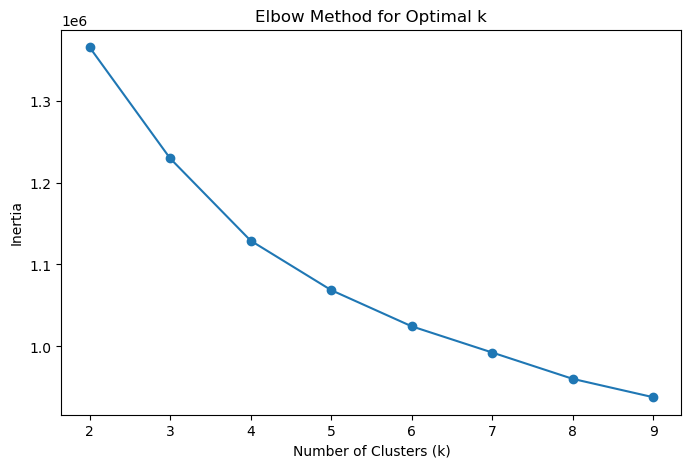

Cluster
0    34490
1    17650
3     9289
2     2554
Name: count, dtype: int64


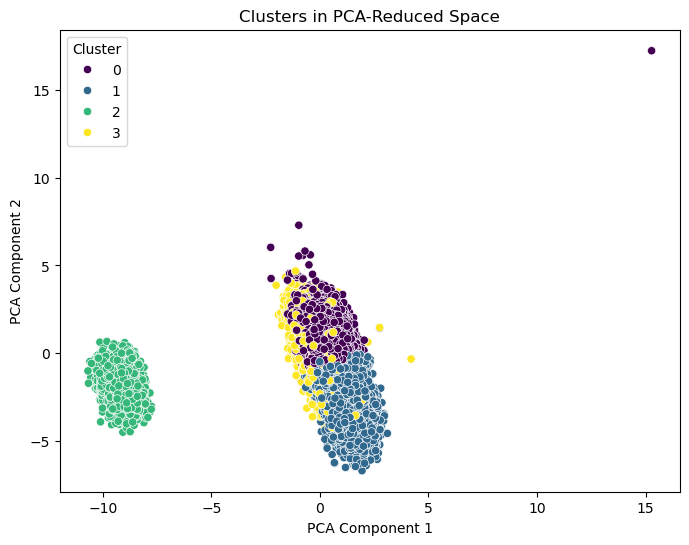

Cluster
0    8594.0
1    1871.0
2     303.0
3    2397.0
Name: Fraud/Shell_company_Fraud, dtype: float64
         Annual_Revenue  Credit_Score  Outstanding_loans  DisbursementGross  \
Cluster                                                                       
0          5.201764e+05    599.497275           5.525167          11.236041   
1          2.026012e+06    600.580850           6.578187          12.725785   
2          5.114553e+05    287.801096          90.031715          11.313751   
3          9.202623e+05    600.805684           5.708257          11.585264   

               Zip     State       Term      NoEmp  
Cluster                                             
0        18.335170  0.394227  63.458133  18.102059  
1        19.130595  0.393006  98.208839  22.847932  
2        14.586922  0.393890  79.685200  17.333986  
3        15.648832  0.394037  78.671870  17.669179  


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest


#Before we run the supervised models lets use unsupervised learning
# Select numerical columns (since dataset is already cleaned)
df_copy = df_clean
num_cols = df_copy.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Standardizing the dataset
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_copy[num_cols])  # Ensure df_scaled is a NumPy array

inertia = []
k_range = range(2, 10)  # Try k from 2 to 10

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.savefig("images/Elbow_method_for_optimalK.png", dpi=300)
plt.show()

# Optimal k (update this based on the elbow method)
optimal_k = 4  

# Run K-Means
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_copy["Cluster"] = kmeans.fit_predict(df_scaled)  # Ensure the column is assigned

# Check if clustering was applied correctly
print(df_copy["Cluster"].value_counts())  # Should show counts for each cluster

# Visualize clusters (using first two PCA components)
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=df_pca[:, 0], y=df_pca[:, 1], hue=df_copy["Cluster"], palette="viridis")
plt.title("Clusters in PCA-Reduced Space")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.savefig("images/cluster_in_pca_reduced_space.png", dpi=300)
plt.show()

#Check if fraud cases (column: Fraud/Shell_company_Fraud) are more frequent in a specific cluster.
fraud_counts = df_copy.groupby("Cluster")["Fraud/Shell_company_Fraud"].sum()
print(fraud_counts)

#Compare mean values of key financial variables (e.g., Annual_Revenue, Credit_Score) per cluster.
cluster_summary = df_copy.groupby("Cluster")[["Annual_Revenue", "Credit_Score", "Outstanding_loans",'DisbursementGross', 'Zip','State','Term','NoEmp']].mean()
print(cluster_summary)



In [29]:
#Splitting data into training and test data

X = df_clean.select_dtypes(include=['int','float'])
X = X.drop(['Fraud/Shell_company_Fraud'], axis=1)

y = df_clean['Fraud/Shell_company_Fraud']  # Target variable (price)

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [30]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 63983 entries, 0 to 99996
Data columns (total 54 columns):
 #   Column                                                                          Non-Null Count  Dtype  
---  ------                                                                          --------------  -----  
 0   State                                                                           63983 non-null  float64
 1   Zip                                                                             63983 non-null  int64  
 2   BankState                                                                       63983 non-null  float64
 3   Term                                                                            63983 non-null  int64  
 4   NoEmp                                                                           63983 non-null  int64  
 5   NewExist                                                                        63983 non-null  float64
 6   CreateJob          

In [85]:
##Lets create metrics List for all the models
metrics_data = []

In [87]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier
import time

# Ensure X_train, X_test, y_train, y_test are properly defined
# Initialize Dummy Classifier with the desired strategy
dummy_clf = DummyClassifier(strategy='stratified') 

#dummy_clf = RandomForestClassifier()
# Measure execution time
basic_start_time = time.time()
dummy_clf.fit(X_train, y_train)
basic_end_time = time.time()

# Predictions
basic_train_preds = dummy_clf.predict(X_train) 
basic_test_preds = dummy_clf.predict(X_test)

# Calculate execution time
basic_execution_time = basic_end_time - basic_start_time
#Analyze the relationship between the features and the target variables
#To find the correlation between number features we can also change the categorical data of house, default and loan to integer


# Evaluate and print metrics
print(f"Accuracy for train baseline classifier: {dummy_clf.score(X_train, y_train):.4f}")
print(f"Accuracy for test baseline classifier: {dummy_clf.score(X_test, y_test):.4f}")

print(f"Train Precision for Dummy Classifier: {precision_score(y_train, basic_train_preds, average='binary'):.4f}")
print(f"Test Precision for Dummy Classifier: {precision_score(y_test, basic_test_preds, average='binary'):.4f}")

print(f"Train Recall for Dummy Classifier: {recall_score(y_train, basic_train_preds, average='binary'):.4f}")
print(f"Test Recall for Dummy Classifier: {recall_score(y_test, basic_test_preds, average='binary'):.4f}")

print(f"Train F1-Score for Dummy Classifier: {f1_score(y_train, basic_train_preds, average='binary'):.4f}")
print(f"Test F1-Score for Dummy Classifier: {f1_score(y_test, basic_test_preds, average='binary'):.4f}")

metrics_data.append({
    "model_name": "DummyClassifier(baseline)",
    "execution_time": basic_execution_time,
    "train_accuracy": dummy_clf.score(X_train, y_train),
    "train_precision": precision_score(y_train, basic_train_preds, average='binary'),
    "train_recall": recall_score(y_train, basic_train_preds, average='binary'),
    "train_f1_score": f1_score(y_train, basic_train_preds, average='binary'),
    "test_accuracy": dummy_clf.score(X_test, y_test),
    "test_precision": precision_score(y_test, basic_test_preds, average='binary'),
    "test_recall": recall_score(y_test, basic_test_preds, average='binary'),
    "test_f1_score": f1_score(y_test, basic_test_preds, average='binary')
})

Accuracy for train baseline classifier: 0.6712
Accuracy for test baseline classifier: 0.6775
Train Precision for Dummy Classifier: 0.2037
Test Precision for Dummy Classifier: 0.2117
Train Recall for Dummy Classifier: 0.2033
Test Recall for Dummy Classifier: 0.2176
Train F1-Score for Dummy Classifier: 0.2035
Test F1-Score for Dummy Classifier: 0.2146


In [89]:
print(df_clean.isnull().mean() * 100)

State                                                                             0.0
Zip                                                                               0.0
BankState                                                                         0.0
NAICS                                                                             0.0
Term                                                                              0.0
NoEmp                                                                             0.0
NewExist                                                                          0.0
CreateJob                                                                         0.0
RetainedJob                                                                       0.0
FranchiseCode                                                                     0.0
UrbanRural                                                                        0.0
RevLineCr                                             

In [91]:
df_clean.shape

(63983, 58)

In [93]:
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report
from sklearn.utils import resample

start_time = time.time()
#X_train_sample, y_train_sample = resample(X_train, y_train, n_samples=25000, random_state=42)  # Adjust sample size
svc_clf = LinearSVC(class_weight='balanced', random_state=42, dual=False).fit(X_train, y_train)
#svc_clf = SVC(kernel='linear', class_weight='balanced', random_state=42).fit(X_train_sample, y_train_sample)
end_time= time.time()

svc_pred_train = svc_clf.predict(X_train)
svc_pred_test = svc_clf.predict(X_test)

print(f"Accuracy for baseline SVC Train {svc_clf.score(X_train,y_train)}")
print(f"Accuracy for baseline SVC Test {svc_clf.score(X_test,y_test)}")

print(f"Train Precision for SVC Classifier: {precision_score(y_train, svc_pred_train, average='binary'):.4f}")
print(f"Test Precision for SVC Classifier: {precision_score(y_test, svc_pred_test, average='binary'):.4f}")

print(f"Train Recall for SVC Classifier: {recall_score(y_train, svc_pred_train, average='binary'):.4f}")
print(f"Test Recall for SVC Classifier: {recall_score(y_test, svc_pred_test, average='binary'):.4f}")

print(f"Train F1-Score for SVC Classifier: {f1_score(y_train, svc_pred_train, average='binary'):.4f}")
print(f"Test F1-Score for SVC Classifier: {f1_score(y_test, svc_pred_test, average='binary'):.4f}")

metrics_data.append({
    "model_name": "SVC(baseline)",
    "execution_time": end_time - start_time,
    "train_accuracy": svc_clf.score(X_train,y_train),
    "train_precision": precision_score(y_train, svc_pred_train, average='binary'),
    "train_recall": recall_score(y_train, svc_pred_train, average='binary'),
    "train_f1_score": f1_score(y_train, svc_pred_train, average='binary'),
    "test_accuracy": svc_clf.score(X_test,y_test),
    "test_precision": precision_score(y_test, svc_pred_test, average='binary'),
    "test_recall": recall_score(y_test, svc_pred_test, average='binary'),
    "test_f1_score": f1_score(y_test, 
                              svc_pred_test, average='binary')
})

Accuracy for baseline SVC Train 0.7139452193959286
Accuracy for baseline SVC Test 0.7128233179651481
Train Precision for SVC Classifier: 0.3905
Test Precision for SVC Classifier: 0.3892
Train Recall for SVC Classifier: 0.6961
Test Recall for SVC Classifier: 0.6950
Train F1-Score for SVC Classifier: 0.5003
Test F1-Score for SVC Classifier: 0.4990


In [95]:
from sklearn.linear_model import LogisticRegression 
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import time

lg_start_time = time.time()
scaler = StandardScaler() 
X_train_scaled = scaler.fit_transform(X_train) 
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=1000, random_state=42) 
#log_reg = GradientBoostingClassifier(n_estimators=100, random_state=42)
log_reg.fit(X_train_scaled, y_train)

lg_end_time = time.time()
log_reg_train_preds = log_reg.predict(X_train_scaled) 
log_reg_test_preds = log_reg.predict(X_test_scaled)

log_reg_train_accuracy = accuracy_score(y_train, log_reg_train_preds) 
log_reg_train_precision = precision_score(y_train, log_reg_train_preds) 
log_reg_train_recall = recall_score(y_train, log_reg_train_preds) 
log_reg_train_f1 = f1_score(y_train, log_reg_train_preds)

log_reg_test_accuracy = accuracy_score(y_test, log_reg_test_preds) 
log_reg_test_precision = precision_score(y_test, log_reg_test_preds) 
log_reg_test_recall = recall_score(y_test, log_reg_test_preds) 
log_reg_test_f1 = f1_score(y_test, log_reg_test_preds)

execution_time_lg =  lg_end_time -lg_start_time 
print(f"Total execution time: {execution_time_lg:.2f} seconds")
print(f"Logistic Regression Train Accuracy: {log_reg_train_accuracy:.4f}") 
print(f"Logistic Regression Test Accuracy: {log_reg_test_accuracy:.4f}")

print(f"Train Precision for Logictics Regression: {log_reg_train_precision}") 
print(f"Test Precision for Logictics Regression: {log_reg_test_precision}")

print(f"TrainRecall for Logictics Regression: {log_reg_train_recall}") 
print(f"Test Recall for Logictics Regression: {log_reg_test_recall}")

print(f"Train F1-Score for Logictics Regression: {log_reg_train_f1}") 
print(f"Test F1-Score for Logictics Regression: {log_reg_test_f1}")

print("\nClassification Report:") 
print(classification_report(y_test, log_reg_test_preds))

metrics_data.append({
    "model_name": "LogisticRegression(default)",
    "execution_time": execution_time_lg,
    "train_accuracy": log_reg_train_accuracy,
    "train_precision": log_reg_train_precision,
    "train_recall": log_reg_train_recall ,
    "train_f1_score": log_reg_train_f1 ,
    "test_accuracy": log_reg_test_accuracy,
    "test_precision": log_reg_test_precision,
    "test_recall": log_reg_test_recall,
    "test_f1_score": log_reg_test_f1
})

Total execution time: 0.25 seconds
Logistic Regression Train Accuracy: 0.7992
Logistic Regression Test Accuracy: 0.7970
Train Precision for Logictics Regression: 0.5290858725761773
Test Precision for Logictics Regression: 0.5161290322580645
TrainRecall for Logictics Regression: 0.2176224838587163
Test Recall for Logictics Regression: 0.21268515001898974
Train F1-Score for Logictics Regression: 0.3083961248654467
Test F1-Score for Logictics Regression: 0.3012372243141474

Classification Report:
              precision    recall  f1-score   support

         0.0       0.82      0.95      0.88     10164
         1.0       0.52      0.21      0.30      2633

    accuracy                           0.80     12797
   macro avg       0.67      0.58      0.59     12797
weighted avg       0.76      0.80      0.76     12797



In [97]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from imblearn.over_sampling import SMOTE

#ecisionTree (default)	DecisionTreeClassifier(max_depth=1, criterion='gini')
#KNN	KNeighborsClassifier(n_neighbors=5, weights='uniform', metric='minkowski')
#SVM	SVC(C=1.0, kernel='rbf', gamma='scale', probability=True)

# Check class distribution before applying SMOTE
print("Class distribution before SMOTE:")
print(y_train.value_counts())

# Apply SMOTE to balance the dataset
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("Class distribution after SMOTE:")
print(y_train_bal.value_counts())

# Define models
models = {
    'DecisionTree(Default)': {'model': DecisionTreeClassifier(random_state=42)},
    'KNeighbors(Default)': {'model': KNeighborsClassifier(n_neighbors=5)},
    'SVM(Default)': {'model': SVC(probability=True, random_state=42)}  # Enable probability for threshold tuning
}


for model_name, model_details in models.items():
    print(f"\nRunning GridSearchCV for {model_name}...")

    start_time = time.time()

    # Create a pipeline with scaling and the model
    pipeline = Pipeline([
        ('scaler', StandardScaler(with_mean=False)),
        ('model', model_details['model'])
    ])

    # Grid Search with 5-fold cross-validation
    grid = GridSearchCV(
        pipeline, 
        param_grid={},  # Hyperparameters can be added here if needed
        cv=5, 
        scoring='roc_auc', 
        verbose=0
    )

    # Train the model
    grid.fit(X_train_bal, y_train_bal)

    end_time = time.time()
    execution_time = end_time - start_time

    # Get predictions
    train_preds = grid.predict(X_train_bal)
    test_preds = grid.predict(X_test)

    # **Check if model predicts both classes**
    print(f"Unique values in train predictions for {model_name}: {np.unique(train_preds)}")
    print(f"Unique values in test predictions for {model_name}: {np.unique(test_preds)}")

    # **Adjust Decision Threshold if Needed**
    if hasattr(grid.best_estimator_, "predict_proba"):  # Only for models with probability estimates
        y_proba = grid.predict_proba(X_test)[:, 1]
        new_threshold = 0.3  # Adjust as needed
        test_preds = (y_proba >= new_threshold).astype(int)

    # Evaluate Model
    train_accuracy = accuracy_score(y_train_bal, train_preds)
    train_precision = precision_score(y_train_bal, train_preds, zero_division=1)
    train_recall = recall_score(y_train_bal, train_preds)
    train_f1 = f1_score(y_train_bal, train_preds)

    test_accuracy = accuracy_score(y_test, test_preds)
    test_precision = precision_score(y_test, test_preds, zero_division=1)
    test_recall = recall_score(y_test, test_preds)
    test_f1 = f1_score(y_test, test_preds)

    print(f" Model - {model_name}")
    print(f" Execution Time - {execution_time:.2f} seconds")
    print(f" Train Accuracy - {train_accuracy:.4f} | Test Accuracy - {test_accuracy:.4f}")
    print(f" Train Precision - {train_precision:.4f} | Test Precision - {test_precision:.4f}")
    print(f" Train Recall - {train_recall:.4f} | Test Recall - {test_recall:.4f}")
    print(f" Train F1-score - {train_f1:.4f} | Test F1-score - {test_f1:.4f}")

    # Store Metrics
    metrics_data.append({
        "model_name": model_name,
        "execution_time": execution_time,
        "train_accuracy": train_accuracy,
        "train_precision": train_precision,
        "train_recall": train_recall,
        "train_f1_score": train_f1,
        "test_accuracy": test_accuracy,
        "test_precision": test_precision,
        "test_recall": test_recall,
        "test_f1_score": test_f1
    })

Class distribution before SMOTE:
Fraud/Shell_company_Fraud
0.0    40654
1.0    10532
Name: count, dtype: int64
Class distribution after SMOTE:
Fraud/Shell_company_Fraud
0.0    40654
1.0    40654
Name: count, dtype: int64

Running GridSearchCV for DecisionTree(Default)...
Unique values in train predictions for DecisionTree(Default): [0. 1.]
Unique values in test predictions for DecisionTree(Default): [0. 1.]
 Model - DecisionTree(Default)
 Execution Time - 10.52 seconds
 Train Accuracy - 1.0000 | Test Accuracy - 0.8690
 Train Precision - 1.0000 | Test Precision - 0.6664
 Train Recall - 1.0000 | Test Recall - 0.7277
 Train F1-score - 1.0000 | Test F1-score - 0.6957

Running GridSearchCV for KNeighbors(Default)...
Unique values in train predictions for KNeighbors(Default): [0. 1.]
Unique values in test predictions for KNeighbors(Default): [0. 1.]
 Model - KNeighbors(Default)
 Execution Time - 6.81 seconds
 Train Accuracy - 0.9078 | Test Accuracy - 0.7124
 Train Precision - 0.9452 | Test P

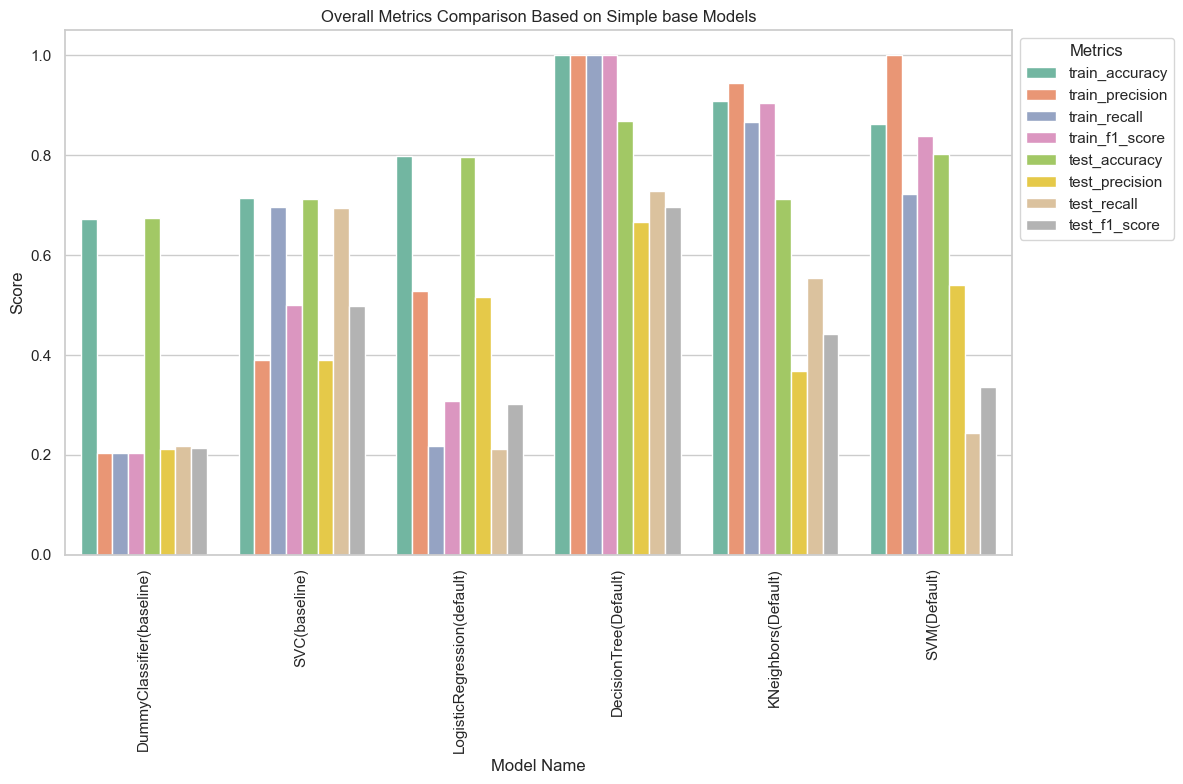

In [99]:
# Set plot style
df_metrics = pd.DataFrame(metrics_data)
sns.set(style="whitegrid")

# Reshape the data for plotting (melt the DataFrame)
df_melted = df_metrics.melt(id_vars=["model_name"], 
                            value_vars=["train_accuracy", "train_precision", "train_recall", "train_f1_score", 
                                        "test_accuracy", "test_precision", "test_recall", "test_f1_score"],
                            var_name="metric", value_name="score")

# Create a combined plot for overall metrics based on the models
plt.figure(figsize=(12, 8))
sns.barplot(x="model_name", y="score", hue="metric", data=df_melted, palette="Set2")

# Customize the plot
plt.title("Overall Metrics Comparison Based on Simple base Models")
plt.ylabel("Score")
plt.xlabel("Model Name")
plt.xticks(rotation=90)
plt.legend(title="Metrics", loc='upper left', bbox_to_anchor=(1, 1))
plt.savefig("images/barplot_for_overall_basemodel_metrics.png", dpi=300)
# Display the plot
plt.tight_layout()
plt.show()

Best Logistic Regression Parameters: {'C': 2.782559402207126, 'penalty': 'l2', 'solver': 'liblinear'}
Total execution time: 440.85 seconds
Logistic Regression Train Accuracy: 0.7992
Logistic Regression Test Accuracy: 0.7971
Train Precision for Logictics Regression: 0.5290993071593534
Test Precision for Logictics Regression: 0.5165745856353591
TrainRecall for Logictics Regression: 0.21752753513102924
Test Recall for Logictics Regression: 0.21306494492973793
Train F1-Score for Logictics Regression: 0.3083030547705558
Test F1-Score for Logictics Regression: 0.3016940037644528

Classification Report:
              precision    recall  f1-score   support

         0.0       0.82      0.95      0.88     10164
         1.0       0.52      0.21      0.30      2633

    accuracy                           0.80     12797
   macro avg       0.67      0.58      0.59     12797
weighted avg       0.76      0.80      0.76     12797



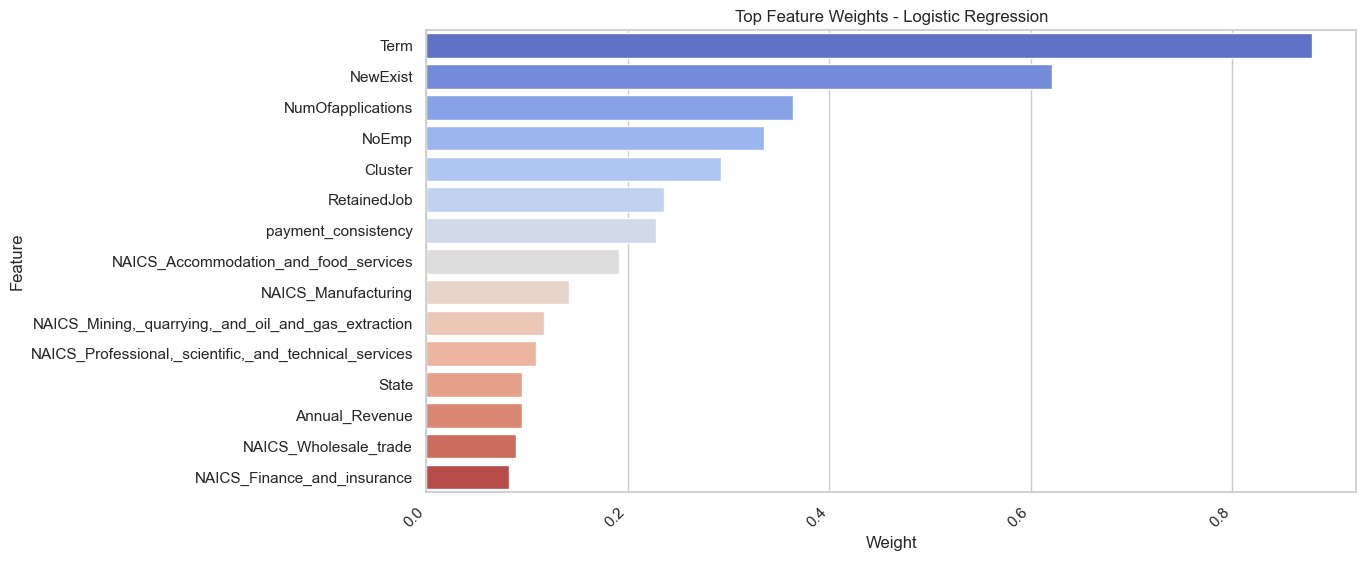

In [101]:
#Running Logistics Regression with tuned hyperparameter to see if the performance improve.

from sklearn.linear_model import LogisticRegression 
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import time

lg_start_time = time.time()
# Store Feature Names Before Scaling
feature_names = X.columns.tolist()  # Ensures feature names are retained

scaler = StandardScaler() 
X_train_scaled = scaler.fit_transform(X_train) 
X_test_scaled = scaler.transform(X_test)

# Define hyperparameter grid for Logistic Regression
log_reg_param_grid = {
    'C': np.logspace(-4, 4, 10),  # Search from 0.0001 to 10000
    'penalty': ['l1', 'l2'],  # Lasso (L1) & Ridge (L2)
    'solver': ['liblinear', 'saga']  # Solvers that support L1 & L2
}

# Perform Grid Search
log_reg = GridSearchCV(LogisticRegression(solver='saga', max_iter=5000), log_reg_param_grid, cv=5, scoring='f1', n_jobs=-1)
log_reg.fit(X_train_scaled, y_train)

# Print Best Parameters
best_log_reg= log_reg.best_estimator_ 
print("Best Logistic Regression Parameters:", log_reg.best_params_)

lg_end_time = time.time()
log_reg_train_preds = log_reg.predict(X_train_scaled) 
log_reg_test_preds = log_reg.predict(X_test_scaled)

log_reg_train_accuracy = accuracy_score(y_train, log_reg_train_preds) 
log_reg_train_precision = precision_score(y_train, log_reg_train_preds) 
log_reg_train_recall = recall_score(y_train, log_reg_train_preds) 
log_reg_train_f1 = f1_score(y_train, log_reg_train_preds)

log_reg_test_accuracy = accuracy_score(y_test, log_reg_test_preds) 
log_reg_test_precision = precision_score(y_test, log_reg_test_preds) 
log_reg_test_recall = recall_score(y_test, log_reg_test_preds) 
log_reg_test_f1 = f1_score(y_test, log_reg_test_preds)

execution_time_lg =  lg_end_time -lg_start_time 
print(f"Total execution time: {execution_time_lg:.2f} seconds")
print(f"Logistic Regression Train Accuracy: {log_reg_train_accuracy:.4f}") 
print(f"Logistic Regression Test Accuracy: {log_reg_test_accuracy:.4f}")

print(f"Train Precision for Logictics Regression: {log_reg_train_precision}") 
print(f"Test Precision for Logictics Regression: {log_reg_test_precision}")

print(f"TrainRecall for Logictics Regression: {log_reg_train_recall}") 
print(f"Test Recall for Logictics Regression: {log_reg_test_recall}")

print(f"Train F1-Score for Logictics Regression: {log_reg_train_f1}") 
print(f"Test F1-Score for Logictics Regression: {log_reg_test_f1}")

print("\nClassification Report:") 
print(classification_report(y_test, log_reg_test_preds))

metrics_data.append({
    "model_name": "LogisticRegression(tuned)",
    "execution_time": execution_time_lg,
    "train_accuracy": log_reg_train_accuracy,
    "train_precision": log_reg_train_precision,
    "train_recall": log_reg_train_recall ,
    "train_f1_score": log_reg_train_f1 ,
    "test_accuracy": log_reg_test_accuracy,
    "test_precision": log_reg_test_precision,
    "test_recall": log_reg_test_recall,
    "test_f1_score": log_reg_test_f1
})


# Step 11: Feature Importance Extraction for Logistic Regression
num_features_model = len(best_log_reg.coef_[0])
num_features_data = len(feature_names)

if num_features_model == num_features_data:
    feature_weights = pd.Series(best_log_reg.coef_[0], index=feature_names)
else:
    feature_weights = pd.Series(best_log_reg.coef_[0], index=feature_names[:num_features_model])

# Sort by absolute value for better visualization
feature_weights = feature_weights.abs().sort_values(ascending=False)

# Keep only the top 15 features
top_n = 15
feature_weights = feature_weights[:top_n]

# Step 12: Plot Feature Importance
plt.figure(figsize=(12, 6))
sns.barplot(x=feature_weights, y=feature_weights.index, hue=feature_weights.index, palette="coolwarm")

plt.xticks(rotation=45, ha="right")  # Rotate labels for better readability
plt.title("Top Feature Weights - Logistic Regression")
plt.xlabel("Weight")
plt.ylabel("Feature")
plt.savefig("images/feature_importance_lg_metrics.png", dpi=300)
plt.show()

Best XGBoost Parameters: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300, 'scale_pos_weight': 2}
XGBoost Accuracy: 0.9237
XGBoost Precision: 0.7973
XGBoost Recall: 0.8439
XGBoost F1-Score: 0.8199
Total execution time: -83.45 seconds
XGB Train Accuracy: 0.9736
XGB Test Accuracy: 0.9237
Train Precision for XGB: 0.9095369792131323
Test Precision for XGB: 0.7972730534625044
TrainRecall for XGB: 0.9680022787694645
Test Recall for XGB: 0.8439042916824915
Train F1-Score for XGB: 0.9378593440964077
Test F1-Score forXGB: 0.8199261992619926

Classification Report:
              precision    recall  f1-score   support

         0.0       0.82      0.95      0.88     10164
         1.0       0.52      0.21      0.30      2633

    accuracy                           0.80     12797
   macro avg       0.67      0.58      0.59     12797
weighted avg       0.76      0.80      0.76     12797



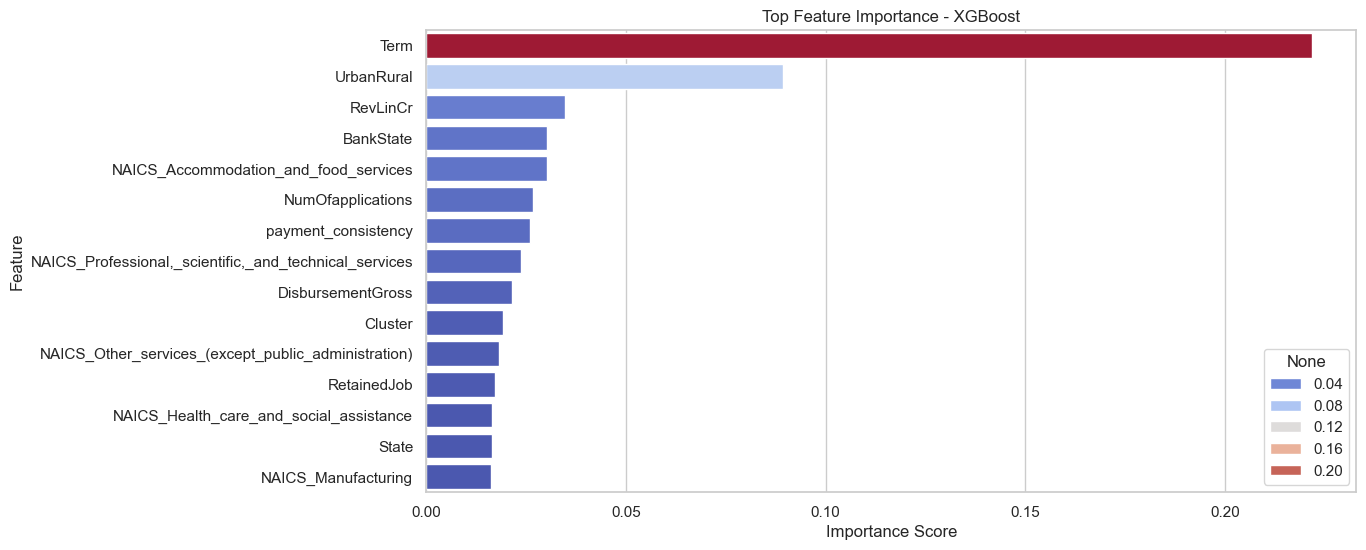

In [103]:
#Running XGBClassifier to see if accuracy is improved
from xgboost import XGBClassifier

xbg_start_time = time.time()
scaler = StandardScaler() 
X_train_scaled = scaler.fit_transform(X_train) 
X_test_scaled = scaler.transform(X_test)

# Define hyperparameter grid for XGBoost
xgb_param_grid = {
    'n_estimators': [100, 200, 300],  
    'max_depth': [3, 5, 7],  
    'learning_rate': [0.01, 0.05, 0.1],  
    'scale_pos_weight': [1, 1.5, 2]  
}

# Perform Grid Search with cross-validation
xgb_grid = GridSearchCV(
    estimator=XGBClassifier(objective='binary:logistic'),
    param_grid=xgb_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

# Fit GridSearchCV on training data
xgb_grid.fit(X_train_scaled, y_train)

xbg_end_time = time.time()

# Get best model from grid search
best_xgb = xgb_grid.best_estimator_
print("Best XGBoost Parameters:", xgb_grid.best_params_)

# Predict on train and test sets
y_pred_xgb_train = best_xgb.predict(X_train_scaled)
y_pred_xgb_test = best_xgb.predict(X_test_scaled)

# Evaluate XGBoost Model
xgb_accuracy_train = accuracy_score(y_train, y_pred_xgb_train)
xgb_precision_train = precision_score(y_train, y_pred_xgb_train)
xgb_recall_train = recall_score(y_train, y_pred_xgb_train)
xgb_f1_train = f1_score(y_train, y_pred_xgb_train)

xgb_accuracy_test = accuracy_score(y_test, y_pred_xgb_test)
xgb_precision_test = precision_score(y_test, y_pred_xgb_test)
xgb_recall_test = recall_score(y_test, y_pred_xgb_test)
xgb_f1_test = f1_score(y_test, y_pred_xgb_test)

print(f"XGBoost Accuracy: {xgb_accuracy_test:.4f}")
print(f"XGBoost Precision: {xgb_precision_test:.4f}")
print(f"XGBoost Recall: {xgb_recall_test:.4f}")
print(f"XGBoost F1-Score: {xgb_f1_test:.4f}")

execution_time_lg =  xbg_start_time - xbg_end_time 
print(f"Total execution time: {execution_time_lg:.2f} seconds")
print(f"XGB Train Accuracy: {xgb_accuracy_train:.4f}") 
print(f"XGB Test Accuracy: {xgb_accuracy_test:.4f}")

print(f"Train Precision for XGB: {xgb_precision_train}") 
print(f"Test Precision for XGB: {xgb_precision_test}")

print(f"TrainRecall for XGB: {xgb_recall_train}") 
print(f"Test Recall for XGB: {xgb_recall_test}")

print(f"Train F1-Score for XGB: {xgb_f1_train}") 
print(f"Test F1-Score forXGB: {xgb_f1_test}")

print("\nClassification Report:") 
print(classification_report(y_test, log_reg_test_preds))

metrics_data.append({
    "model_name": "XGBoost",
    "execution_time": execution_time_lg,
    "train_accuracy": xgb_accuracy_train,
    "train_precision": xgb_precision_train,
    "train_recall": xgb_recall_train ,
    "train_f1_score": xgb_f1_train ,
    "test_accuracy": xgb_accuracy_test,
    "test_precision": xgb_precision_test,
    "test_recall":xgb_recall_test,
    "test_f1_score": xgb_f1_test
})

# Ensure feature names are strings
feature_names = [str(col) for col in X.columns]  

# Check the length of feature importance values vs. feature names
num_features_model = len(best_xgb.feature_importances_)
num_features_data = len(feature_names)

# Align feature names with importance values
if num_features_model == num_features_data:
    feature_importance = pd.Series(best_xgb.feature_importances_, index=feature_names)
else:
    feature_importance = pd.Series(best_xgb.feature_importances_, index=feature_names[:num_features_model])

# Sort for better visualization
feature_importance = feature_importance.sort_values(ascending=False)

# Keep only the top 15 features
top_n = 15
feature_importance = feature_importance[:top_n]

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(x=feature_importance, y=feature_importance.index, hue=feature_importance,palette="coolwarm")

plt.title("Top Feature Importance - XGBoost")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.savefig("images/barplot_for_feature_importance_XGBoost_metrics.png", dpi=300)
plt.show()

In [105]:
models = {
    'RandonTree(Tuned)': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'model__max_depth': [None, 10, 20, 30],
            'model__min_samples_split': [2, 5, 10],
            'model__min_samples_leaf': [1, 2, 4],
            'model__max_features': ['sqrt', 'log2']
        }
    },
    'KNeighbors(Tuned)': {
        'model': KNeighborsClassifier(),
        'params': {
            'model__n_neighbors': [3, 5, 7],
            'model__weights': ['uniform', 'distance'],
            'model__p': [1, 2],  # Manhattan (1) or Euclidean (2) distance
            'model__algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute']
        }
    }
}


for model_name, model_details in models.items():
    print(f"\nRunning GridSearchCV for {model_name}...")
    start_time = time.time()
    
    # Create a pipeline
    pipeline = Pipeline([
        ('scaler', StandardScaler(with_mean=False)),  # Apply scaling
        ('model', model_details['model'])  # Add the model dynamically
    ])

    # Grid Search with 5-fold cross-validation
    grid = GridSearchCV(
        pipeline, 
        param_grid=model_details['params'], 
        cv=5, 
        scoring='roc_auc', 
        verbose=0,
        error_score='raise'
    )

    # Fit the grid search
    grid.fit(X_train, y_train)

    end_time = time.time()
    
    # Best parameters and model performance
    print(f"Best Parameters for {model_name}: {grid.best_params_}")
    print(f"Best Cross-Validation Accuracy for {model_name}: {grid.best_score_}")
    
    # Evaluate the best model on the test set
    best_model = grid.best_estimator_
    
    end_time = time.time()
    train_preds = best_model.predict(X_train) 
    test_preds = best_model.predict(X_test)

    train_accuracy_train = accuracy_score(y_train, train_preds) 
    train_precision_train = precision_score(y_train, train_preds) 
    train_recall_train = recall_score(y_train, train_preds) 
    train_f1_train = f1_score(y_train, train_preds)

    test_accuracy_test = accuracy_score(y_test, test_preds) 
    test_precision_test = precision_score(y_test, test_preds) 
    test_recall_test = recall_score(y_test, test_preds) 
    test_f1_test = f1_score(y_test, test_preds)

    execution_time = end_time -start_time
    print(f"Total execution time: {execution_time_lg:.2f} seconds")
    print(f"{model_name}Train Accuracy: {train_accuracy_train:.4f}") 
    print(f"{model_name} Test Accuracy: {test_accuracy_test:.4f}")

    print(f"{model_name}Train Precision : {train_precision_train}") 
    print(f"{model_name}Test Precision : {test_precision_test}")

    print(f"{model_name}TrainRecall  {train_recall_train}") 
    print(f"{model_name}Test Recall {test_recall_test}")

    print(f"{model_name}Train F1-Score : {train_f1_train}") 
    print(f"{model_name}Test F1-Score : {test_f1_test}")
    
    metrics_data.append({
        "model_name": model_name,
        "execution_time" : execution_time,
        "train_accuracy": train_accuracy,
        "train_precision": train_precision,
        "train_recall": train_recall ,
        "train_f1_score": train_f1 ,
        "test_accuracy": test_accuracy,
        "test_precision": test_precision,
        "test_recall": test_recall,
        "test_f1_score": test_f1
    })


Running GridSearchCV for RandonTree(Tuned)...
Best Parameters for RandonTree(Tuned): {'model__max_depth': 30, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 2}
Best Cross-Validation Accuracy for RandonTree(Tuned): 0.936558871658522
Total execution time: -83.45 seconds
RandonTree(Tuned)Train Accuracy: 1.0000
RandonTree(Tuned) Test Accuracy: 0.8988
RandonTree(Tuned)Train Precision : 1.0
RandonTree(Tuned)Test Precision : 0.8338323353293413
RandonTree(Tuned)TrainRecall  1.0
RandonTree(Tuned)Test Recall 0.6346372958602354
RandonTree(Tuned)Train F1-Score : 1.0
RandonTree(Tuned)Test F1-Score : 0.7207246064265689

Running GridSearchCV for KNeighbors(Tuned)...
Best Parameters for KNeighbors(Tuned): {'model__algorithm': 'auto', 'model__n_neighbors': 7, 'model__p': 1, 'model__weights': 'distance'}
Best Cross-Validation Accuracy for KNeighbors(Tuned): 0.7539233167435067
Total execution time: -83.45 seconds
KNeighbors(Tuned)Train Accuracy: 1.0000
KNeighbor

In [107]:
models = {
      'SVM(tuned)': {
        'model': SVC(random_state=42),
        'params': {
            'model__C': [0.1, 1, 10],
            'model__kernel': ['rbf'],
            'model__gamma': ['auto'],
            'model__class_weight': [None, 'balanced']
        }
    }
}

for model_name, model_details in models.items():
    print(f"\nRunning GridSearchCV for {model_name}...")
    start_time = time.time()
    
    # Create a pipeline
    pipeline = Pipeline([
        ('scaler', StandardScaler(with_mean=False)),  # Apply scaling
        ('model', model_details['model'])  # Add the model dynamically
    ])

    # Grid Search with 5-fold cross-validation
    grid = GridSearchCV(
        pipeline, 
        param_grid=model_details['params'], 
        cv=5, 
        scoring='roc_auc', 
        verbose=0,
        error_score='raise'
    )

    # Fit the grid search
    grid.fit(X_train, y_train)

    end_time = time.time()
    
    # Best parameters and model performance
    print(f"Best Parameters for {model_name}: {grid.best_params_}")
    print(f"Best Cross-Validation Accuracy for {model_name}: {grid.best_score_}")
    
    # Evaluate the best model on the test set
    best_model = grid.best_estimator_
    
    end_time = time.time()
    train_preds = best_model.predict(X_train) 
    test_preds = best_model.predict(X_test)

    train_accuracy = accuracy_score(y_train, train_preds) 
    train_precision = precision_score(y_train, train_preds) 
    train_recall = recall_score(y_train, train_preds) 
    train_f1 = f1_score(y_train, train_preds)

    test_accuracy = accuracy_score(y_test, test_preds) 
    test_precision = precision_score(y_test, test_preds) 
    test_recall = recall_score(y_test, test_preds) 
    test_f1 = f1_score(y_test, test_preds)

    execution_time = end_time -start_time

    metrics_data.append({
        "model_name": model_name,
        "execution_time" : execution_time,
        "train_accuracy": train_accuracy,
        "train_precision": train_precision,
        "train_recall": train_recall ,
        "train_f1_score": train_f1 ,
        "test_accuracy": test_accuracy,
        "test_precision": test_precision,
        "test_recall": test_recall,
        "test_f1_score": test_f1
    })

    print(f" {model_name}      |     {execution_time}        |        {train_accuracy}	|  {test_accuracy}   |")
    print(f" {train_precision} |  {test_precision} | {train_recall} | {test_recall} | {train_f1} | {test_f1} |")


Running GridSearchCV for SVM(tuned)...
Best Parameters for SVM(tuned): {'model__C': 1, 'model__class_weight': 'balanced', 'model__gamma': 'auto', 'model__kernel': 'rbf'}
Best Cross-Validation Accuracy for SVM(tuned): 0.8305017383880564
 SVM(tuned)      |     6809.423076629639        |        0.7974055405775017	|  0.7704930843166368   |
 0.5047346270750526 |  0.46448598130841123 | 0.819882263577668 | 0.7550322825674136 | 0.6248191027496383 | 0.5751482713727759 |


In [109]:
import numpy as np
import pandas as pd
import time
from sklearn.ensemble import (
    RandomForestClassifier, 
    AdaBoostClassifier, 
    BaggingClassifier, 
    StackingClassifier, 
    VotingClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Standardize Data (Needed for KNN)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Model Dictionary to Store Results
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Boosted RF (AdaBoost)": AdaBoostClassifier(
        estimator=RandomForestClassifier(n_estimators=50, random_state=42),
        n_estimators=50, learning_rate=0.1, random_state=42, algorithm='SAMME'  
    ),
    "Stacking (RF + LogReg)": StackingClassifier(
        estimators=[('rf', RandomForestClassifier(n_estimators=50, random_state=42))], 
        final_estimator=LogisticRegression()
    ),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Bagging KNN": BaggingClassifier(
        estimator=KNeighborsClassifier(n_neighbors=5), 
        n_estimators=50, random_state=42
    ),
    "Voting (KNN + RF)": VotingClassifier(
        estimators=[('knn', KNeighborsClassifier(n_neighbors=5)), 
                    ('rf', RandomForestClassifier(n_estimators=50, random_state=42))], 
        voting='hard'
    )
}

for model_name, model in models.items():
    start_time = time.time()  # Start time tracking
    model.fit(X_train, y_train)
    end_time = time.time()  # End time tracking
    
    # Predictions
    train_preds = model.predict(X_train)
    test_preds = model.predict(X_test)
    
    #Compute Metrics
    train_accuracy = accuracy_score(y_train, train_preds)
    train_precision = precision_score(y_train, train_preds)
    train_recall = recall_score(y_train, train_preds)
    train_f1 = f1_score(y_train, train_preds)

    test_accuracy = accuracy_score(y_test, test_preds)
    test_precision = precision_score(y_test, test_preds)
    test_recall = recall_score(y_test, test_preds)
    test_f1 = f1_score(y_test, test_preds)

    execution_time = end_time - start_time  # Compute Execution Time

    print(f"Total execution time: {execution_time_lg:.2f} seconds")
    print(f"{model_name}Train Accuracy: {train_accuracy:.4f}") 
    print(f"{model_name} Test Accuracy: {test_accuracy:.4f}")

    print(f"{model_name}Train Precision : {train_precision}") 
    print(f"{model_name}Test Precision : {test_precision}")

    print(f"{model_name}TrainRecall  {train_recall}") 
    print(f"{model_name}Test Recall {test_recall}")

    print(f"{model_name}Train F1-Score : {train_f1}") 
    print(f"{model_name}Test F1-Score : {test_f1}")
    
    #Store in List
    metrics_data.append({
        "Model": model_name,
        "Execution Time (s)": execution_time,
        "Train Accuracy": train_accuracy,
        "Train Precision": train_precision,
        "Train Recall": train_recall,
        "Train F1-score": train_f1,
        "Test Accuracy": test_accuracy,
        "Test Precision": test_precision,
        "Test Recall": test_recall,
        "Test F1-score": test_f1
    })


Total execution time: -83.45 seconds
Random ForestTrain Accuracy: 1.0000
Random Forest Test Accuracy: 0.8956
Random ForestTrain Precision : 1.0
Random ForestTest Precision : 0.8280222559433486
Random ForestTrainRecall  0.999905051272313
Random ForestTest Recall 0.6217242688947968
Random ForestTrain F1-Score : 0.9999525233822343
Random ForestTest F1-Score : 0.7101952277657266
Total execution time: -83.45 seconds
Boosted RF (AdaBoost)Train Accuracy: 1.0000
Boosted RF (AdaBoost) Test Accuracy: 0.9000
Boosted RF (AdaBoost)Train Precision : 1.0
Boosted RF (AdaBoost)Test Precision : 0.8471010774756286
Boosted RF (AdaBoost)TrainRecall  1.0
Boosted RF (AdaBoost)Test Recall 0.6270413976452716
Boosted RF (AdaBoost)Train F1-Score : 1.0
Boosted RF (AdaBoost)Test F1-Score : 0.7206460061108686
Total execution time: -83.45 seconds
Stacking (RF + LogReg)Train Accuracy: 1.0000
Stacking (RF + LogReg) Test Accuracy: 0.8959
Stacking (RF + LogReg)Train Precision : 0.999905051272313
Stacking (RF + LogReg)Te

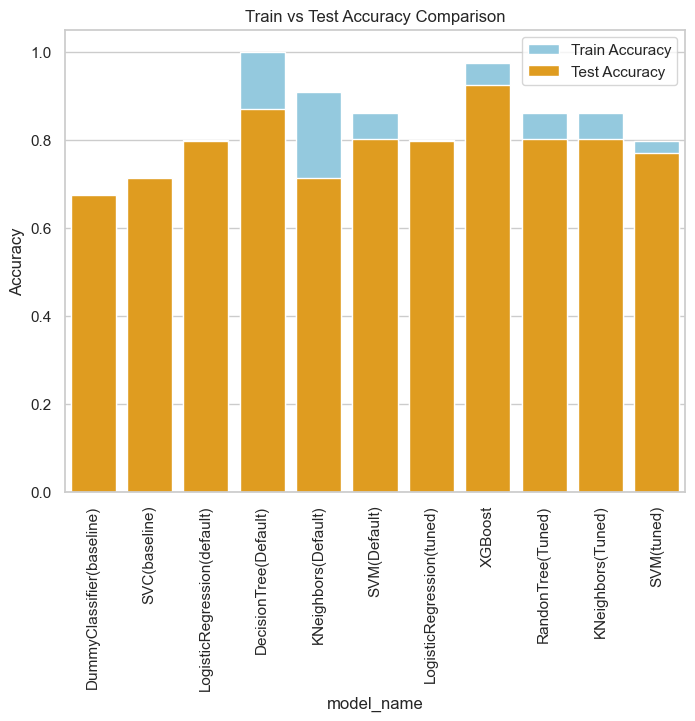

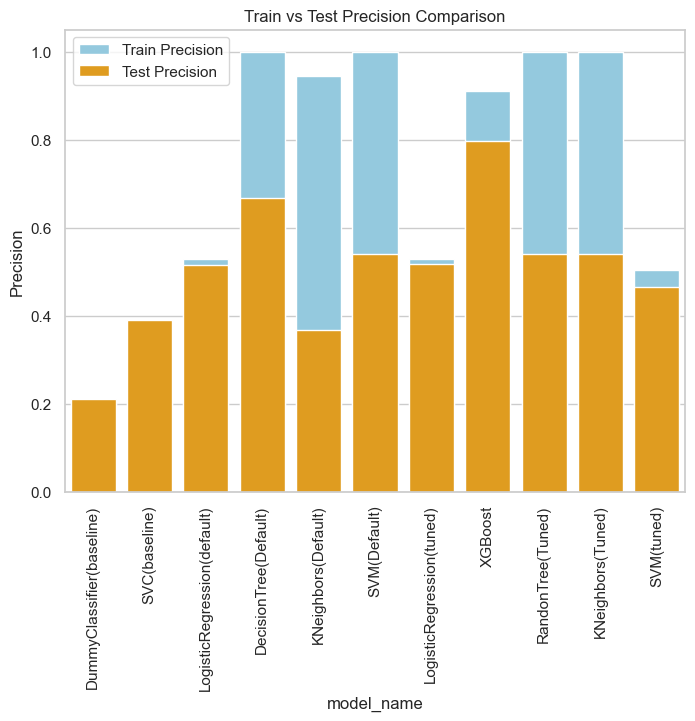

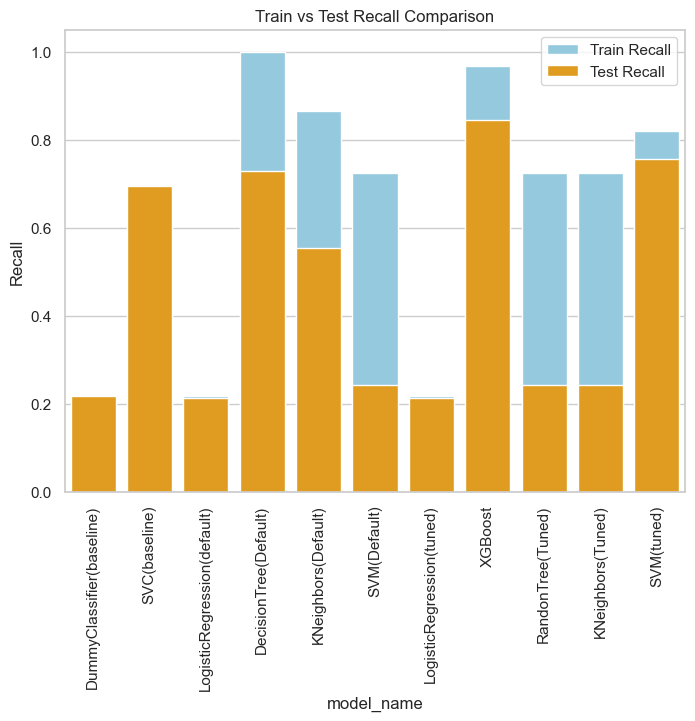

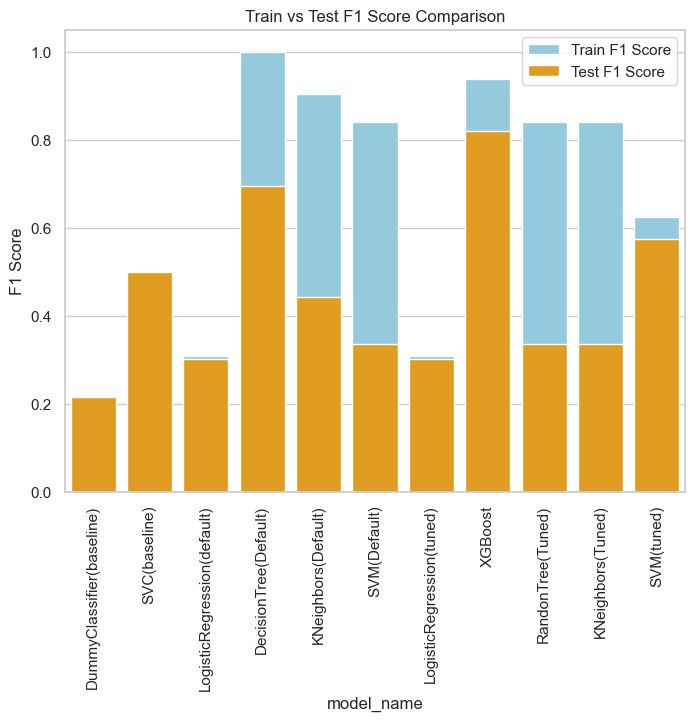

In [111]:
df_metrics = pd.DataFrame(metrics_data)
# Set plot style
sns.set(style="whitegrid")

# 1. Accuracy comparison (train vs test)
plt.figure(figsize=(8, 6))
sns.barplot(x="model_name", y="train_accuracy", data=df_metrics, color="skyblue", label="Train Accuracy")
sns.barplot(x="model_name", y="test_accuracy", data=df_metrics, color="orange", label="Test Accuracy")
plt.title("Train vs Test Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=90)
plt.legend()
plt.savefig("images/barplot_train_vs_test_Accuracy_for_models.png", dpi=300)
plt.show()

# 2. Precision comparison (train vs test)
plt.figure(figsize=(8, 6))
sns.barplot(x="model_name", y="train_precision", data=df_metrics, color="skyblue", label="Train Precision")
sns.barplot(x="model_name", y="test_precision", data=df_metrics, color="orange", label="Test Precision")
plt.title("Train vs Test Precision Comparison")
plt.ylabel("Precision")
plt.xticks(rotation=90)
plt.legend()
plt.savefig("images/barplot_train_vs_test_Precision_for_models.png", dpi=300)
plt.show()

# 3. Recall comparison (train vs test)
plt.figure(figsize=(8, 6))
sns.barplot(x="model_name", y="train_recall", data=df_metrics, color="skyblue", label="Train Recall")
sns.barplot(x="model_name", y="test_recall", data=df_metrics, color="orange", label="Test Recall")
plt.title("Train vs Test Recall Comparison")
plt.ylabel("Recall")
plt.xticks(rotation=90)
plt.legend()
plt.savefig("images/barplot_train_vs_test_Recall_for_models.png", dpi=300)
plt.show()

# 4. F1 Score comparison (train vs test)
plt.figure(figsize=(8, 6))
sns.barplot(x="model_name", y="train_f1_score", data=df_metrics, color="skyblue", label="Train F1 Score")
sns.barplot(x="model_name", y="test_f1_score", data=df_metrics, color="orange", label="Test F1 Score")
plt.title("Train vs Test F1 Score Comparison")
plt.ylabel("F1 Score")
plt.xticks(rotation=90)
plt.legend()
plt.savefig("images/barplot_train_vs_test_F1Score_for_models.png", dpi=300)
plt.show()



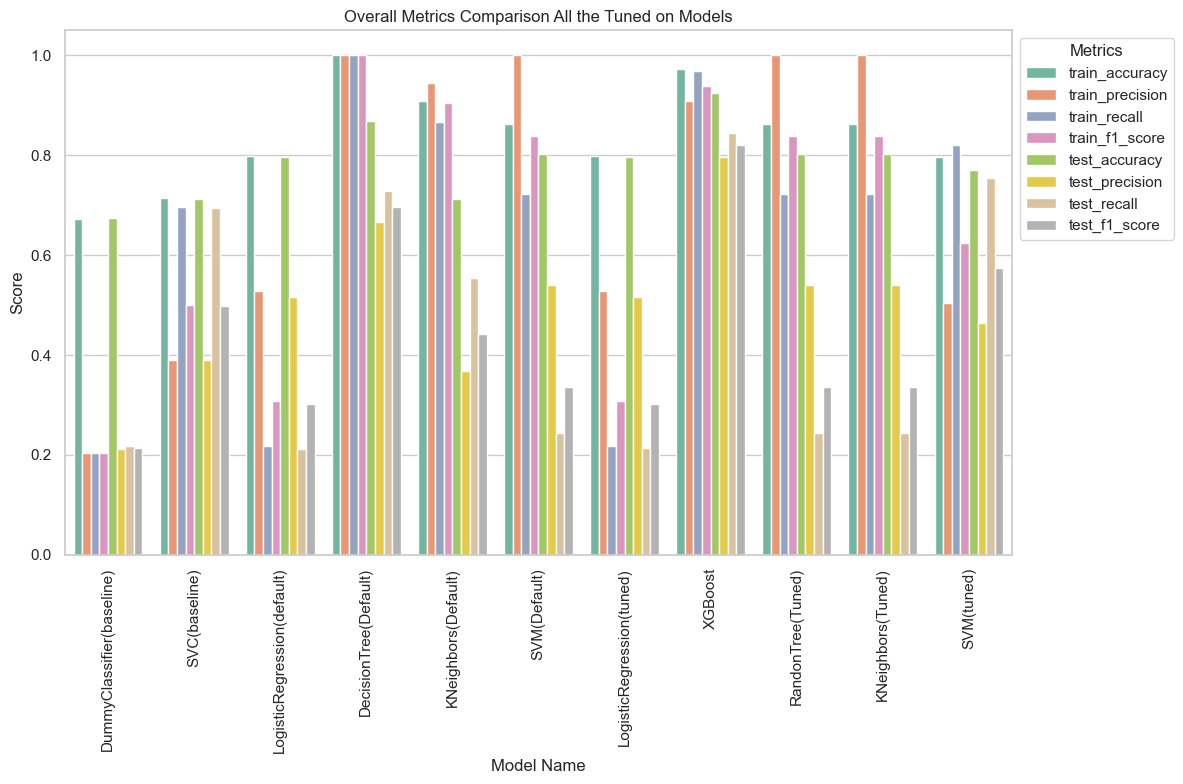

In [113]:
# Reshape the data for plotting (melt the DataFrame)
df_melted = df_metrics.melt(id_vars=["model_name"], 
                            value_vars=["train_accuracy", "train_precision", "train_recall", "train_f1_score", 
                                        "test_accuracy", "test_precision", "test_recall", "test_f1_score"],
                            var_name="metric", value_name="score")

# Create a combined plot for overall metrics based on the models
plt.figure(figsize=(12, 8))
sns.barplot(x="model_name", y="score", hue="metric", data=df_melted, palette="Set2")

# Customize the plot
plt.title("Overall Metrics Comparison All the Tuned on Models")
plt.ylabel("Score")
plt.xlabel("Model Name")
plt.xticks(rotation=90)
plt.legend(title="Metrics", loc='upper left', bbox_to_anchor=(1, 1))
plt.savefig("images/barplot_for_overall_tuned_model_metrics.png", dpi=300)
# Display the plot
plt.tight_layout()
plt.show()